In [1]:
# ==========================================================
# IMPORTACIONES
# ==========================================================
!pip install --quiet catboost lightgbm xgboost imbalanced-learn shap statsmodels
# %pip install catboost
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import requests
warnings.filterwarnings('ignore')

# Scikit-learn — modelado y validación
from sklearn.model_selection  import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.ensemble         import RandomForestClassifier
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.metrics          import (classification_report, confusion_matrix,
                                      accuracy_score, roc_curve, auc,
                                      precision_score, recall_score,
                                      f1_score, roc_auc_score,
                                      precision_recall_curve, average_precision_score)
from sklearn.preprocessing    import label_binarize

from scipy.stats import weibull_min
from scipy.special import gamma as gamma_fn
from scipy.stats import pearsonr
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import make_scorer
from sklearn.metrics import fbeta_score
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
from statsmodels.stats.contingency_tables import mcnemar

# Balanceo de clases
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

# Modelos de ensamble
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Prueba estadística — justificación del umbral de 5 días del MTFS
from scipy.stats import mannwhitneyu

# SHAP — interpretabilidad
import shap

# Configuración global de gráficos
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['figure.dpi']    = 100
sns.set_theme(style="whitegrid")

print("=======================================================")
print("   IMPORTACIONES COMPLETADAS                           ")
print("=======================================================")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.0 MB/s eta 0:00:00
   IMPORTACIONES COMPLETADAS                           



   CONFIGURACIÓN DE ENTORNO: SISTEMA INTELIGENTE DE CARGA 
[*] Intentando conectar con Google Drive para automatizar rutas...
Mounted at /content/drive
[✓] Carpeta de trabajo establecida en tu Google Drive: /content/drive/MyDrive/Proyecto de grado/Código


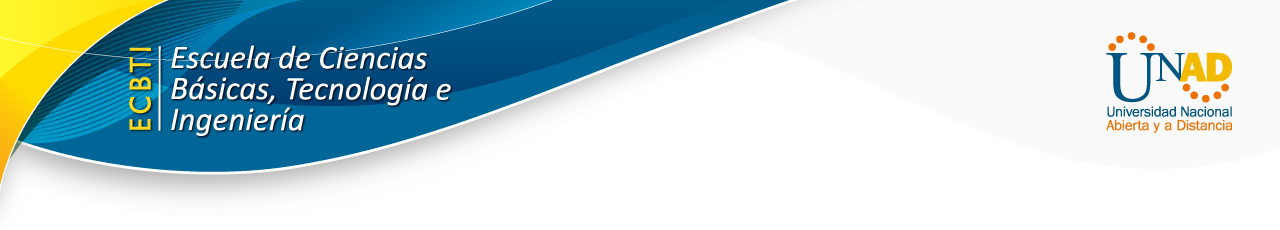


[✓] ¡Excelente! El archivo 'DB_ProyectoGrado - DB_HISTORICO.csv' está listo para ser procesado.


In [2]:
# CONFIGURACIÓN DE ENTORNO: CONEXIÓN A DRIVE O CARGA LOCAL
print("\n======================================================")
print("   CONFIGURACIÓN DE ENTORNO: SISTEMA INTELIGENTE DE CARGA ")
print("========================================================")
import os
from IPython.display import Image, display

# Variables de archivos requeridos
archivo_entrada = 'DB_ProyectoGrado - DB_HISTORICO.csv'
ruta_imagen = 'UNAD.png'
ruta_proyecto_drive = '/content/drive/MyDrive/Proyecto de grado/Código'

usando_drive = False

# 1. --- INTENTO DE CONEXIÓN AUTOMÁTICA A DRIVE (Para ti) ---
try:
    from google.colab import drive
    # Solo intentamos montar si estamos en Colab y el tutor/usuario decide aceptar el diálogo de Drive
    print("[*] Intentando conectar con Google Drive para automatizar rutas...")
    drive.mount('/content/drive', force_remount=False)

    if os.path.exists(ruta_proyecto_drive):
        os.chdir(ruta_proyecto_drive)
        print(f"[✓] Carpeta de trabajo establecida en tu Google Drive: {os.getcwd()}")
        usando_drive = True
    else:
        print(f"[!] No se encontró la ruta '{ruta_proyecto_drive}' en este Google Drive.")
        print("[i] Modo de compatibilidad activado: Se trabajará en el entorno local de Colab.")
except Exception as e:
    print("[i] Trabajando en entorno local o sin permisos de Google Drive.")

# 2. --- VERIFICACIÓN Y ASISTENCIA DE CARGA (Para tu tutor) ---
# Si no se logró usar Drive, verificamos si los archivos están en la raíz temporal de Colab
if not usando_drive:
    # Cambiamos al directorio por defecto de Colab
    os.chdir('/content')
    print(f"[i] Directorio actual: {os.getcwd()}")

    # Comprobamos si el CSV o la imagen hacen falta en el entorno local
    faltan_archivos = not os.path.exists(archivo_entrada) or not os.path.exists(ruta_imagen)

    if faltan_archivos:
        print("\n" + "!"*60)
        print(" ATENCIÓN TUTOR / EVALUADOR:")
        print(f" Para ejecutar este notebook correctamente, por favor cargue los ")
        print(f" siguientes archivos en la barra lateral izquierda de Colab (icono de carpeta):")
        if not os.path.exists(archivo_entrada):
            print(f"  - {archivo_entrada}")
        if not os.path.exists(ruta_imagen):
            print(f"  - {ruta_imagen}")
        print("!"*60 + "\n")

        # Opcional: Esto abrirá de forma interactiva una ventana para que el tutor suba los archivos desde su PC
        from google.colab import files
        print("[*] Seleccione los archivos faltantes desde su computador para continuar:")
        subidos = files.upload()

# 3. --- CARGA DE LA IMAGEN INSTITUCIONAL ---
if os.path.exists(ruta_imagen):
    display(Image(ruta_imagen, width=1080, height=230))
else:
    print(f"[X] Alerta: No se encontró '{ruta_imagen}' para visualizar.")

# 4. --- VERIFICACIÓN FINAL ---
if os.path.exists(archivo_entrada):
    print(f"\n[✓] ¡Excelente! El archivo '{archivo_entrada}' está listo para ser procesado.")
else:
    raise FileNotFoundError(f"ERROR CRÍTICO: Falta el archivo '{archivo_entrada}'. El script no puede continuar.")

# Universidad Nacional Abierta y a Distancia
### Escuela de Ciencias Básicas Tecnología e Ingeniería

### Especialización en Ciencia de Datos y Analítica

# Diseño e implementación de un sistema analítico predictivo para la optimización de indicadores de mantenimiento de equipos hidráulicos en el sector de la minería en el caribe colombiano (Periodo 2022 - 2025)


====================================================
# Autor: Harol Diaz
# Asesor: Andres Felipe Solis Pino
====================================================

In [3]:
# =============================================================
#     BLOQUE  1: PERFILAMIENTO CUANTITATIVO
# =============================================================
print("\n=====================================================")
print("  BLOQUE 1: PERFILAMIENTO CUANTITATIVO Y AUDITORÍA     ")
print("=======================================================")

# 1. Recuperamos de forma segura la ruta del archivo
nombre_archivo = globals().get('archivo_entrada', 'DB_ProyectoGrado - DB_HISTORICO.csv')

# 2. Validamos y recuperamos
if 'df_raw' in globals():
    df_local = globals()['df_raw']
else:

    if os.path.exists(nombre_archivo):
        print(f"[*] Cargando dataset en memoria desde: {nombre_archivo}...")
        df_local = pd.read_csv(nombre_archivo, low_memory=False)
        globals()['df_raw'] = df_local
    else:
        raise NameError(
            f"La variable 'df_raw' no está en memoria y no se encontró el archivo '{nombre_archivo}' para cargarla."
        )

# --- IMPRESIÓN DE DATOS DEL DATASET ---
print(f"[✓] Archivo encontrado: '{nombre_archivo}'")
print(f"[✓] Filas totales   : {len(df_local):,}")
print(f"[✓] Columnas totales: {len(df_local.columns)}")

# --- PERFILAMIENTO CUANTITATIVO DEL DATASET CRUDO ---
print("\n--- PERFILAMIENTO DEL DATASET ORIGINAL (ANTES DEL ETL) ---")

try:
    fechas_raw = pd.to_datetime(df_local['Fecha Hora Inicial'], format='mixed', errors='coerce')
    print(f"    Rango temporal  : {fechas_raw.min().date()} → {fechas_raw.max().date()}")
except Exception:
    print("    Rango temporal  : no disponible (columna con formato mixto)")

print(f"    Equipos únicos  : {df_local['Equipo'].nunique()}")
print(f"    Sistemas únicos : {df_local['SISTEMA'].nunique() if 'SISTEMA' in df_local.columns else 'N/A'}")

# --- AUDITORÍA DE NULOS Y DISTRIBUCIÓN ---
nulos = (df_local.isnull().mean() * 100).round(2).sort_values(ascending=False)
print(f"\n    Top 5 columnas con más nulos (%):")
for col, pct in nulos.head(5).items():
    print(f"      {col:<35}: {pct}%")

if 'SISTEMA' in df_local.columns:
    print(f"\n    Distribución completa de SISTEMAS encontrados:")
    # totalidad de los sistemas
    dist = df_local['SISTEMA'].astype(str).str.strip().str.upper().value_counts()
    for index, (sist, cnt) in enumerate(dist.items(), 1):
        print(f"      {index:02d}. {sist:<20}: {cnt:,} registros")


  BLOQUE 1: PERFILAMIENTO CUANTITATIVO Y AUDITORÍA     
[*] Cargando dataset en memoria desde: DB_ProyectoGrado - DB_HISTORICO.csv...
[✓] Archivo encontrado: 'DB_ProyectoGrado - DB_HISTORICO.csv'
[✓] Filas totales   : 20,384
[✓] Columnas totales: 33

--- PERFILAMIENTO DEL DATASET ORIGINAL (ANTES DEL ETL) ---
    Rango temporal  : 2022-12-24 → 2026-12-05
    Equipos únicos  : 27
    Sistemas únicos : 10

    Top 5 columnas con más nulos (%):
      Column 32                          : 100.0%
      Column 33                          : 100.0%
      Cant. (Según MTBF)                 : 77.51%
      Cant. (Según MTBS)                 : 7.85%
      Horas Down (Evs)                   : 3.38%

    Distribución completa de SISTEMAS encontrados:
      01. SEIS                : 13,445 registros
      02. SAC                 : 1,791 registros
      03. SHI                 : 1,503 registros
      04. FALSO REPORTE       : 1,344 registros
      05. SEL                 : 689 registros
      06. SPO  

In [4]:
# =====================================================================
#     BLOQUE 2: ETL — LIMPIEZA Y EXCLUSIONES TÉCNICAS
# =====================================================================
print("\n==============================================================")
print("   BLOQUE 2: ETL - LIMPIEZA DE CADENAS Y EXCLUSIONES TÉCNICAS   ")
print("================================================================")

# 1. Recuperamos
if 'df_raw' in globals():
    df_local_raw = globals()['df_raw']
else:
    raise NameError(
        "La variable 'df_raw' no está en memoria. Ejecuta primero la celda de carga de datos."
    )

# RF-05 — Normalización de horas: convierte texto de Excel a decimal
def limpiar_convertir_flotante(valor):
    if pd.isna(valor):                  return 0.0
    if isinstance(valor, (int, float)): return float(valor)
    s = str(valor).strip().replace('.', '').replace(',', '.')
    try:    return float(s)
    except: return 0.0

# Aplicamos la limpieza
df_local_raw['Horas_Down_Numeric'] = df_local_raw['Horas Down (Evs)'].apply(limpiar_convertir_flotante)

# RT-01 — Sanitización de cadenas de texto (strip + upper)
for col in ['SISTEMA', 'SUB SISTEMA', 'Tajo']:
    if col in df_local_raw.columns:
        df_local_raw[col] = df_local_raw[col].astype(str).str.strip().str.upper()

# Palas dadas de baja — excluidas del análisis
equipos_retirados = [60131, 60132, 60133, 60134, 60135, 60136]

# Sistemas a excluir del análisis
sistemas_excluidos = ['SEIS', 'FALSO REPORTE', 'DAÑO OPERACIONAL']

# Filtrado del dataset
df_flota_activa_local = df_local_raw[
    (~df_local_raw['SISTEMA'].isin(sistemas_excluidos)) &
    (~df_local_raw['Equipo'].isin(equipos_retirados))
].copy()

# 2. Registramos df_flota_activa en la memoria global de Colab para que otras celdas la usen
globals()['df_flota_activa'] = df_flota_activa_local

# 3. Creamos una referencia local
df_activa = df_flota_activa_local

print(f"[✓] Sistemas excluidos del análisis: {sistemas_excluidos}")
print(f"[✓] Equipos retirados excluidos    : {equipos_retirados}")

# Verificación explícita de los 21 equipos activos
equipos_activos = sorted(df_activa['Equipo'].unique().tolist())
print(f"[✓] Equipos activos en el análisis ({len(equipos_activos)} palas):")
print(f"    {equipos_activos}")
print(f"[✓] Confirma rango: {min(equipos_activos)} → {max(equipos_activos)}")

filas_antes   = len(df_local_raw)
filas_despues = len(df_activa)
print(f"[✓] Registros antes del ETL  : {filas_antes:,}")
print(f"[✓] Registros eliminados      : {filas_antes - filas_despues:,} "
      f"(SEIS + FALSO REPORTE + DAÑO OPERACIONAL + palas retiradas)")
print(f"[✓] Registros flota activa    : {filas_despues:,} (21 Palas Hitachi EX3600R)")
print(f"[✓] Equipos activos únicos    : {df_activa['Equipo'].nunique()}")


   BLOQUE 2: ETL - LIMPIEZA DE CADENAS Y EXCLUSIONES TÉCNICAS   
[✓] Sistemas excluidos del análisis: ['SEIS', 'FALSO REPORTE', 'DAÑO OPERACIONAL']
[✓] Equipos retirados excluidos    : [60131, 60132, 60133, 60134, 60135, 60136]
[✓] Equipos activos en el análisis (21 palas):
    [60137, 60138, 60139, 60140, 60141, 60142, 60143, 60144, 60145, 60146, 60147, 60148, 60149, 60150, 60151, 60152, 60153, 60154, 60155, 60156, 60157]
[✓] Confirma rango: 60137 → 60157
[✓] Registros antes del ETL  : 20,384
[✓] Registros eliminados      : 16,259 (SEIS + FALSO REPORTE + DAÑO OPERACIONAL + palas retiradas)
[✓] Registros flota activa    : 4,125 (21 Palas Hitachi EX3600R)
[✓] Equipos activos únicos    : 21



 BLOQUE  3: DIAGNÓSTICO OPERATIVO Y LÍNEA BASE                  

--- TABLA: HORAS EN TALLER POR FALLAS IMPREVISTAS (FLOTA ACTIVA) ---
 Equipo  Frecuencia_Fallas  Total_Horas_Down  MTTR_Correctivo_Horas
  60138                440           1729.54                   3.93
  60137                294           1478.30                   5.03
  60141                322           1346.11                   4.18
  60140                319           1278.08                   4.01
  60139                324           1186.14                   3.66
  60144                265           1096.43                   4.14
  60142                269           1068.51                   3.97
  60147                216            959.69                   4.44
  60143                250            866.40                   3.47
  60146                271            836.43                   3.09
  60148                149            821.57                   5.51
  60145                202            778.92    

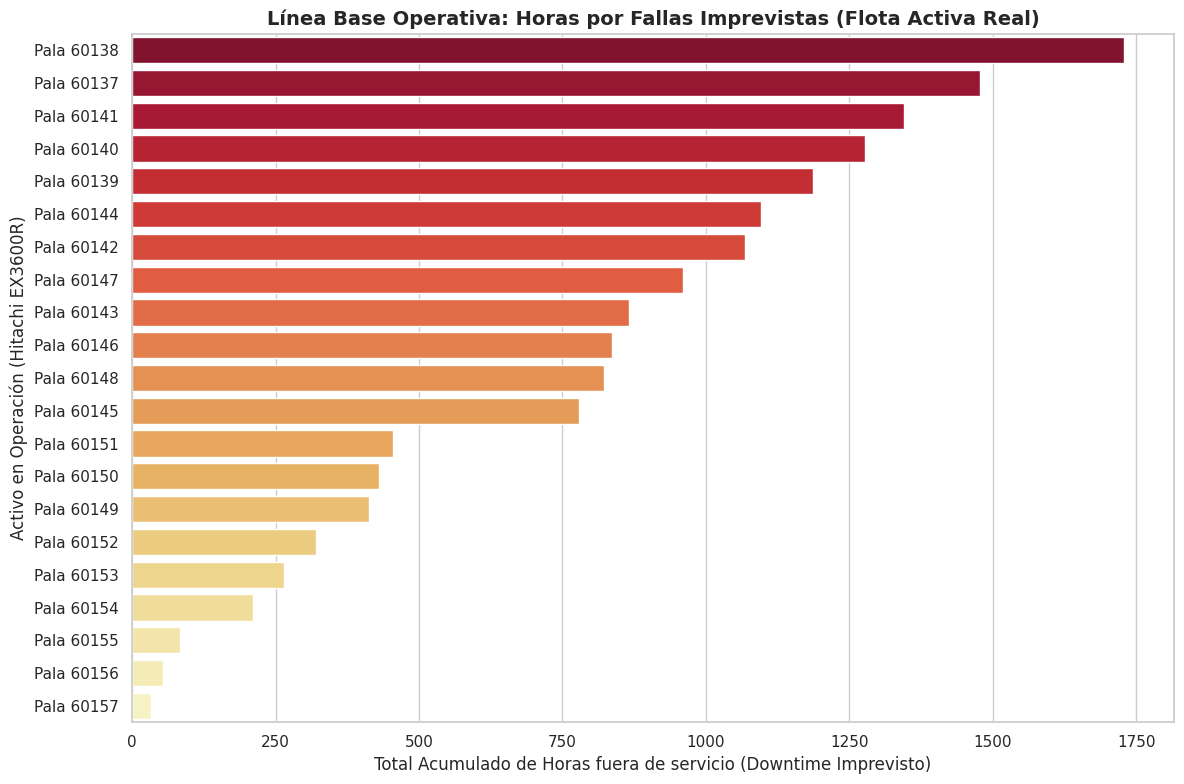

In [5]:
# =====================================================================
#    BLOQUE 3: DIAGNÓSTICO OPERATIVO — LÍNEA BASE (EL ANTES)
# =====================================================================
print("\n==============================================================")
print(" BLOQUE  3: DIAGNÓSTICO OPERATIVO Y LÍNEA BASE                  ")
print("================================================================")


# --- RECUPERACIÓN SEGURA DEL DATASET FLOTA ACTIVA ---
if 'df_flota_activa' in globals():
    df_activa = globals()['df_flota_activa']
else:
    raise NameError(
        "La variable 'df_flota_activa' no se encuentra en memoria. "
        "Por favor, ejecuta primero la celda del Bloque 2 (ETL)."
    )

# Agrupación y cálculo de indicadores básicos por equipo
reporte_flota_activa = df_activa.groupby('Equipo').agg(
    Frecuencia_Fallas     = ('SISTEMA', 'count'),
    Total_Horas_Down      = ('Horas_Down_Numeric', 'sum'),
    MTTR_Correctivo_Horas = ('Horas_Down_Numeric', 'mean')
).reset_index().sort_values(by='Total_Horas_Down', ascending=False)

reporte_flota_activa['Total_Horas_Down']      = reporte_flota_activa['Total_Horas_Down'].round(2)
reporte_flota_activa['MTTR_Correctivo_Horas'] = reporte_flota_activa['MTTR_Correctivo_Horas'].round(2)

print("\n--- TABLA: HORAS EN TALLER POR FALLAS IMPREVISTAS (FLOTA ACTIVA) ---")
print(reporte_flota_activa.to_string(index=False))

# Gráfica 1 — Radiografía de downtime por activo
print("\n[Desplegando Gráfica 1...]")
plt.figure(figsize=(12, 8))
df_g1 = reporte_flota_activa.copy()
df_g1['Equipo_Label'] = "Pala " + df_g1['Equipo'].astype(str)
sns.barplot(data=df_g1, x='Total_Horas_Down', y='Equipo_Label',
            palette='YlOrRd_r', hue='Equipo_Label', legend=False)
plt.title('Línea Base Operativa: Horas por Fallas Imprevistas (Flota Activa Real)',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Acumulado de Horas fuera de servicio (Downtime Imprevisto)', fontsize=12)
plt.ylabel('Activo en Operación (Hitachi EX3600R)', fontsize=12)
plt.tight_layout()
plt.savefig('1_radiografia_flota_activa.png', dpi=300)
plt.show()


 BLOQUE 4: ALGORITMO DE CALIDAD - RETRABAJOS HIDRÁULICOS (MTFS) 

--- TABLA: CALIDAD OPERATIVA Y PÉRDIDA DE MTFS POR ACTIVO ---
 Equipo  Total_Fallas_SHI  Cantidad_Retrabajos  MTFS_Promedio_Dias  Porcentaje_Retrabajos_%
  60137               110                   51                 9.5                    46.36
  60138               123                   55                11.2                    44.72
  60148                46                   19                13.4                    41.30
  60141                99                   40                14.0                    40.40
  60142                92                   34                13.4                    36.96
  60147                74                   27                12.0                    36.49
  60140               102                   37                14.2                    36.27
  60144                67                   24                21.2                    35.82
  60143                83                  

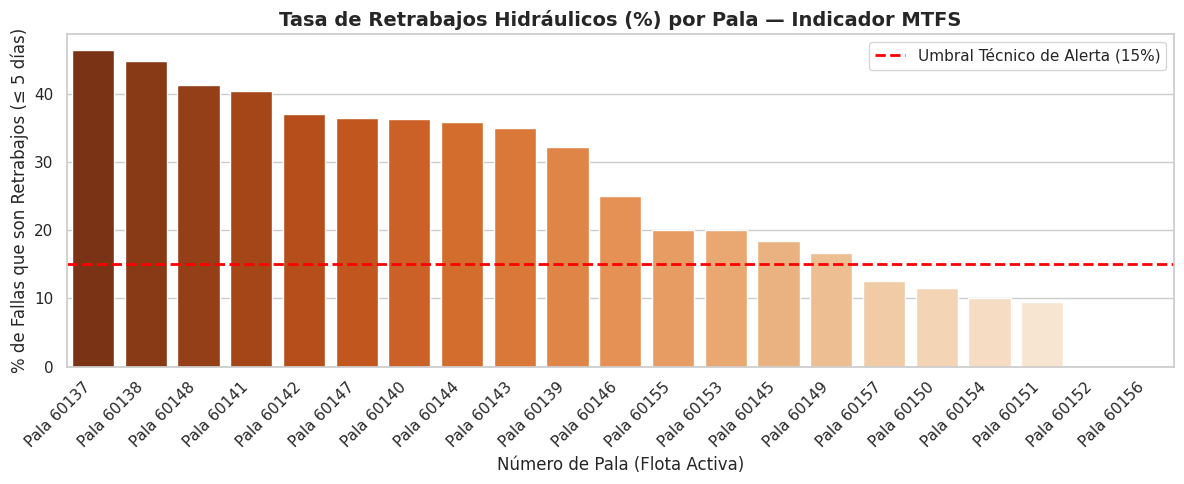

In [6]:
# =====================================================================
#   BLOQUE 4: ALGORITMO DE CALIDAD — RETRABAJOS HIDRÁULICOS (MTFS)
# =====================================================================
print("\n==============================================================")
print(" BLOQUE 4: ALGORITMO DE CALIDAD - RETRABAJOS HIDRÁULICOS (MTFS) ")
print("================================================================")

# RF-03 — Aislar sistema crítico Hidráulico (SHI)
df_hidraulico = df_activa[df_activa['SISTEMA'] == 'SHI'].copy()

# RT-03 — Conversión temporal
df_hidraulico['Fecha_Hora_Inicial_DT'] = pd.to_datetime(
    df_hidraulico['Fecha Hora Inicial'], format='mixed', errors='coerce'
)
df_hidraulico = df_hidraulico.sort_values(by=['Equipo', 'Fecha_Hora_Inicial_DT'])

# RF-04 — Cálculo secuencial del MTFS
df_hidraulico['Fecha_Evento_Anterior'] = (
    df_hidraulico.groupby('Equipo')['Fecha_Hora_Inicial_DT'].shift(1)
)
df_hidraulico['Dias_Desde_Ultima_Falla'] = (
    df_hidraulico['Fecha_Hora_Inicial_DT'] - df_hidraulico['Fecha_Evento_Anterior']
).dt.total_seconds() / (24 * 3600)

# Regla de calidad: ≤ 5 días entre fallas del mismo sistema = retrabajo
df_hidraulico['Es_Retrabajo'] = df_hidraulico['Dias_Desde_Ultima_Falla'].apply(
    lambda x: 1 if (not pd.isna(x) and x <= 5.0) else 0
)

# Guardamos el dataframe hidráulico limpio en las variables globales
globals()['df_hidraulico'] = df_hidraulico

# Reporte MTFS por activo
reporte_mtfs = df_hidraulico.groupby('Equipo').agg(
    Total_Fallas_SHI  = ('Es_Retrabajo', 'count'),
    Cantidad_Retrabajos = ('Es_Retrabajo', 'sum'),
    MTFS_Promedio_Dias  = ('Dias_Desde_Ultima_Falla', 'mean')
).reset_index()

reporte_mtfs['Porcentaje_Retrabajos_%'] = (
    (reporte_mtfs['Cantidad_Retrabajos'] / reporte_mtfs['Total_Fallas_SHI']) * 100
).round(2)
reporte_mtfs['MTFS_Promedio_Dias'] = reporte_mtfs['MTFS_Promedio_Dias'].round(1)
reporte_mtfs = reporte_mtfs.sort_values(by='Porcentaje_Retrabajos_%', ascending=False)

print("\n--- TABLA: CALIDAD OPERATIVA Y PÉRDIDA DE MTFS POR ACTIVO ---")
print(reporte_mtfs.to_string(index=False))

# Balance global de la clase objetivo
total_shi     = len(df_hidraulico)
total_retrab  = df_hidraulico['Es_Retrabajo'].sum()
pct_retrab    = (total_retrab / total_shi * 100).round(2)
print(f"\n[i] Balance de la clase objetivo (dataset SHI completo):")
print(f"    Fallas normales (clase 0): {total_shi - total_retrab:,}  ({100-pct_retrab:.1f}%)")
print(f"    Retrabajos      (clase 1): {total_retrab:,}  ({pct_retrab:.1f}%)")
print(f"    → Desbalance confirmado: se aplicará SMOTE-Tomek dentro de cada fold "
      f"de validación cruzada (sin class_weight, para evitar doble penalización).")

# Gráfica 2 — Tasa de retrabajos por pala
print("\n[Desplegando Gráfica 2...]")
plt.figure(figsize=(12, 5))
reporte_mtfs['Equipo_Str'] = "Pala " + reporte_mtfs['Equipo'].astype(str)
sns.barplot(data=reporte_mtfs, x='Equipo_Str', y='Porcentaje_Retrabajos_%',
            palette='Oranges_r', hue='Equipo_Str', legend=False)
plt.axhline(y=15, color='red', linestyle='--', linewidth=2,
            label='Umbral Técnico de Alerta (15%)')
plt.title('Tasa de Retrabajos Hidráulicos (%) por Pala — Indicador MTFS',
          fontsize=14, fontweight='bold')
plt.xlabel('Número de Pala (Flota Activa)', fontsize=12)
plt.ylabel('% de Fallas que son Retrabajos (≤ 5 días)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('2_tasa_retrabajos_flota_activa.png', dpi=300)
plt.show()

In [7]:
# =====================================================================
#    BLOQUE 4B PRUEBA DE MANN-WHITNEY
#    JUSTIFICACIÓN ESTADÍSTICA DEL UMBRAL DE 5 DÍAS
# =====================================================================
print("\n==============================================================")
print("  BLOQUE 4B: PRUEBA U DE MANN-WHITNEY (UMBRAL DE 5 DÍAS)        ")
print("================================================================")
print("""
H0: el conteo de fallas acumuladas en los 30 días previos al evento
    (Fallas_Ult_30d) tiene la MISMA distribución en los eventos que sí
    recurren en <= 5 días (retrabajo) que en los que no recurren.
H1: los retrabajos ocurren sobre equipos con un desgaste acumulado
    previo SIGNIFICATIVAMENTE mayor.
Nota: Fallas_Ult_30d se calcula usando EXCLUSIVAMENTE fallas anteriores
al evento evaluado (fechas[:i]), por lo que la prueba no incorpora
información del propio evento que está siendo clasificado (sin fuga).
""")

def contar_fallas_ventana_mw(grupo, dias):
    fechas = grupo['Fecha_Hora_Inicial_DT'].values
    conteos = []
    for i, f in enumerate(fechas):
        ventana_inicio = f - np.timedelta64(dias, 'D')
        conteos.append(((fechas[:i] >= ventana_inicio) & (fechas[:i] < f)).sum())
    return conteos

# Estas mismas columnas se vuelven a calcular en el BLOQUE 5 (allí quedan
# fijas como parte del vector de características); aquí se recalculan de
# forma autocontenida para poder reportar la prueba estadística temprano.
df_hidraulico['Fallas_Ult_30d'] = df_hidraulico.groupby('Equipo', group_keys=False).apply(
    lambda g: pd.Series(contar_fallas_ventana_mw(g, 30), index=g.index))
df_hidraulico['Fallas_Ult_60d'] = df_hidraulico.groupby('Equipo', group_keys=False).apply(
    lambda g: pd.Series(contar_fallas_ventana_mw(g, 60), index=g.index))

resultados_mw = {}
for ventana in ['Fallas_Ult_30d', 'Fallas_Ult_60d']:
    df_mw = df_hidraulico.dropna(subset=[ventana, 'Dias_Desde_Ultima_Falla']).copy()
    grupo_retrabajo = df_mw.loc[df_mw['Es_Retrabajo'] == 1, ventana]
    grupo_normal    = df_mw.loc[df_mw['Es_Retrabajo'] == 0, ventana]
    u_stat, p_value = mannwhitneyu(grupo_retrabajo, grupo_normal, alternative='two-sided')
    n1, n2 = len(grupo_retrabajo), len(grupo_normal)
    # Tamaño del efecto: correlación rank-biserial (r = 2U/(n1*n2) - 1).
    # Convenciones de Cohen: |r| ~0.1 pequeño, ~0.3 mediano, ~0.5 grande.
    rank_biserial = (2 * u_stat) / (n1 * n2) - 1
    resultados_mw[ventana] = {
        'n_retrabajo': n1, 'n_normal': n2,
        'mediana_retrabajo': float(grupo_retrabajo.median()),
        'mediana_normal': float(grupo_normal.median()),
        'U': float(u_stat), 'p_value': float(p_value),
        'rank_biserial_r': round(float(rank_biserial), 4),
    }
    print(f"[Mann-Whitney {ventana}] U={u_stat:.0f}  p={p_value:.4g}  "
          f"r={rank_biserial:.4f}  mediana_retrabajo={grupo_retrabajo.median()}  "
          f"mediana_normal={grupo_normal.median()}")

print(f"\n[✓] Conclusión: se rechaza H0 (p < 0,001) con un tamaño de efecto "
      f"grande (r ≈ {resultados_mw['Fallas_Ult_30d']['rank_biserial_r']:.2f}). "
      f"El umbral de 5 días captura eventos sobre equipos en degradación "
      f"activa, no un artefacto arbitrario del calendario.")

# Robustez: repetir con umbrales alternos (3, 5, 7, 10 días), para mostrar
# que la asociación no depende frágilmente del corte exacto de 5 días.
print("\n[i] Prueba de robustez con umbrales alternos:")
for umbral in [3, 5, 7, 10]:
    col_u = f'Es_Retrabajo_{umbral}'
    df_hidraulico[col_u] = df_hidraulico['Dias_Desde_Ultima_Falla'].apply(
        lambda x, u=umbral: 1 if (not pd.isna(x) and x <= u) else 0)
    df_tmp = df_hidraulico.dropna(subset=['Fallas_Ult_30d'])
    g1 = df_tmp.loc[df_tmp[col_u] == 1, 'Fallas_Ult_30d']
    g0 = df_tmp.loc[df_tmp[col_u] == 0, 'Fallas_Ult_30d']
    if len(g1) > 5 and len(g0) > 5:
        u2, p2 = mannwhitneyu(g1, g0, alternative='two-sided')
        r2 = (2 * u2) / (len(g1) * len(g0)) - 1
        print(f"    Umbral {umbral:>2} días → n_retrabajo={len(g1):<4} p={p2:.4g}  r={r2:.4f}")


  BLOQUE 4B: PRUEBA U DE MANN-WHITNEY (UMBRAL DE 5 DÍAS)        

H0: el conteo de fallas acumuladas en los 30 días previos al evento
    (Fallas_Ult_30d) tiene la MISMA distribución en los eventos que sí
    recurren en <= 5 días (retrabajo) que en los que no recurren.
H1: los retrabajos ocurren sobre equipos con un desgaste acumulado
    previo SIGNIFICATIVAMENTE mayor.
Nota: Fallas_Ult_30d se calcula usando EXCLUSIVAMENTE fallas anteriores
al evento evaluado (fechas[:i]), por lo que la prueba no incorpora
información del propio evento que está siendo clasificado (sin fuga).

[Mann-Whitney Fallas_Ult_30d] U=207328  p=8.702e-50  r=0.5357  mediana_retrabajo=3.0  mediana_normal=1.0
[Mann-Whitney Fallas_Ult_60d] U=187580  p=1.222e-26  r=0.3894  mediana_retrabajo=5.0  mediana_normal=3.0

[✓] Conclusión: se rechaza H0 (p < 0,001) con un tamaño de efecto grande (r ≈ 0.54). El umbral de 5 días captura eventos sobre equipos en degradación activa, no un artefacto arbitrario del calendario.

[


  BLOQUE 4C: AJUSTE DE WEIBULL SOBRE INTERVALOS MTFS (ΔT)  

El parámetro de forma (β) de la distribución de Weibull diagnostica el
régimen de falla dominante del Sistema Hidráulico (SHI):
  β < 1  → mortalidad infantil: las fallas se agrupan poco después de una
           intervención previa (compatible con retrabajos por reparación
           incompleta, el mismo fenómeno que mide la variable objetivo).
  β ≈ 1  → fallas aleatorias, tasa de falla constante en el tiempo
           (proceso de Poisson homogéneo).
  β > 1  → desgaste progresivo (wear-out): la probabilidad de falla
           aumenta cuanto más tiempo pasa desde la última intervención.

[✓] Muestra                 : 1,085 intervalos ΔT (todo el SHI, 21 palas)
[✓] Parámetro de forma (β)  : 0.770
[✓] Parámetro de escala (η) : 15.54 días
[i] Interpretación de confiabilidad: mortalidad infantil (β<1) — las fallas del SHI se agrupan poco después de una intervención previa, consistente con el fenómeno de retrabajo que motiva 

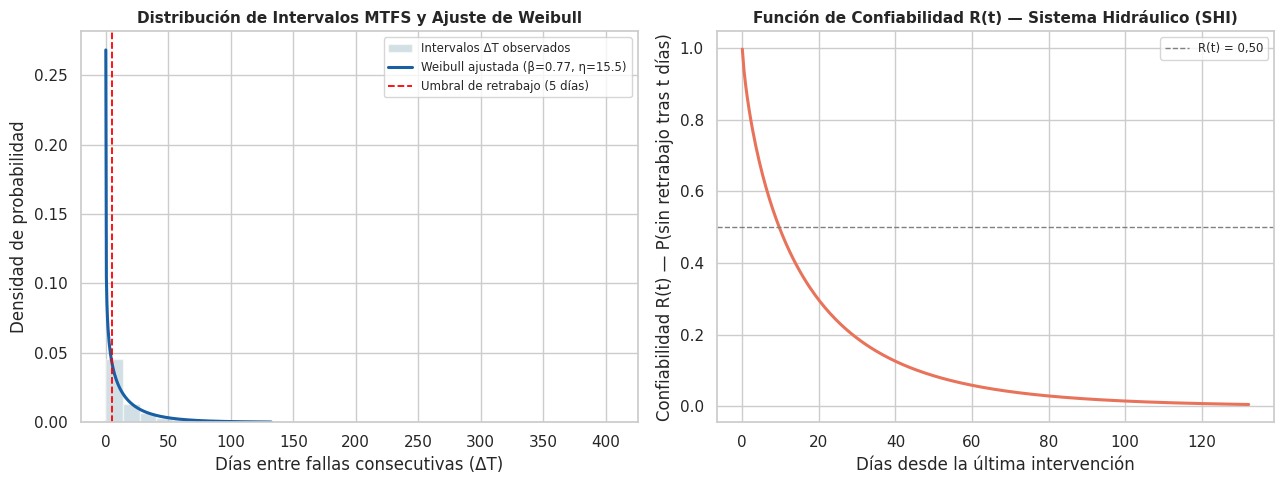

In [ ]:
# =================================================================
#    BLOQUE 4C (RONDA 2): AJUSTE DE DISTRIBUCIÓN DE WEIBULL
#    SOBRE LOS INTERVALOS MTFS (TEORÍA CLÁSICA DE CONFIABILIDAD)
# =================================================================
print("\n=========================================================")
print("  BLOQUE 4C: AJUSTE DE WEIBULL SOBRE INTERVALOS MTFS (ΔT)  ")
print("===========================================================")
print("""
El parámetro de forma (β) de la distribución de Weibull diagnostica el
régimen de falla dominante del Sistema Hidráulico (SHI):
  β < 1  → mortalidad infantil: las fallas se agrupan poco después de una
           intervención previa (compatible con retrabajos por reparación
           incompleta, el mismo fenómeno que mide la variable objetivo).
  β ≈ 1  → fallas aleatorias, tasa de falla constante en el tiempo
           (proceso de Poisson homogéneo).
  β > 1  → desgaste progresivo (wear-out): la probabilidad de falla
           aumenta cuanto más tiempo pasa desde la última intervención.
""")

intervalos_mtfs = df_hidraulico['Dias_Desde_Ultima_Falla'].dropna()
intervalos_mtfs = intervalos_mtfs[intervalos_mtfs > 0]

# Ajuste por máxima verosimilitud (floc=0: el reloj de cada intervalo
# arranca en 0 en la fecha de la intervención previa)
beta_forma, loc_weibull, eta_escala = weibull_min.fit(intervalos_mtfs, floc=0)

print(f"[✓] Muestra                 : {len(intervalos_mtfs):,} intervalos ΔT (todo el SHI, 21 palas)")
print(f"[✓] Parámetro de forma (β)  : {beta_forma:.3f}")
print(f"[✓] Parámetro de escala (η) : {eta_escala:.2f} días")

if beta_forma < 0.95:
    interpretacion_weibull = ("mortalidad infantil (β<1) — las fallas del SHI se agrupan poco después de una "
                               "intervención previa, consistente con el fenómeno de retrabajo que motiva este proyecto")
elif beta_forma <= 1.05:
    interpretacion_weibull = "fallas aproximadamente aleatorias (β≈1) — tasa de falla ~constante en el tiempo, sin un patrón dominante de desgaste"
else:
    interpretacion_weibull = "desgaste progresivo (β>1) — la probabilidad de falla crece con el tiempo transcurrido desde la última intervención"
print(f"[i] Interpretación de confiabilidad: {interpretacion_weibull}")

mtfs_teorico  = eta_escala * gamma_fn(1 + 1/beta_forma)
mtfs_empirico = intervalos_mtfs.mean()
vida_mediana  = eta_escala * (np.log(2)) ** (1/beta_forma)
print(f"[✓] MTFS empírico (media aritmética ΔT)   : {mtfs_empirico:.2f} días")
print(f"[✓] MTFS teórico (Weibull, η·Γ(1+1/β))    : {mtfs_teorico:.2f} días")
print(f"[i] Vida mediana estimada (R(t)=0,50)     : {vida_mediana:.2f} días entre fallas")

print("\n[Desplegando Gráfica — Ajuste de Weibull y Función de Confiabilidad R(t)...]")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
x_vals = np.linspace(0.01, intervalos_mtfs.quantile(0.99), 300)

ax1.hist(intervalos_mtfs, bins=30, density=True, alpha=0.55, color='#AEC6CF',
         label='Intervalos ΔT observados')
ax1.plot(x_vals, weibull_min.pdf(x_vals, beta_forma, loc_weibull, eta_escala),
         color='#185FA5', lw=2.2, label=f'Weibull ajustada (β={beta_forma:.2f}, η={eta_escala:.1f})')
ax1.axvline(x=5, color='red', linestyle='--', lw=1.3, label='Umbral de retrabajo (5 días)')
ax1.set_xlabel('Días entre fallas consecutivas (ΔT)')
ax1.set_ylabel('Densidad de probabilidad')
ax1.set_title('Distribución de Intervalos MTFS y Ajuste de Weibull', fontsize=11, fontweight='bold')
ax1.legend(fontsize=8.5)

r_t = 1 - weibull_min.cdf(x_vals, beta_forma, loc_weibull, eta_escala)
ax2.plot(x_vals, r_t, color='#E8735A', lw=2.2)
ax2.axhline(0.5, color='gray', linestyle='--', lw=1, label='R(t) = 0,50')
ax2.set_xlabel('Días desde la última intervención')
ax2.set_ylabel('Confiabilidad R(t) — P(sin retrabajo tras t días)')
ax2.set_title('Función de Confiabilidad R(t) — Sistema Hidráulico (SHI)', fontsize=11, fontweight='bold')
ax2.legend(fontsize=8.5)
plt.tight_layout()
plt.savefig('3_weibull_mtfs.png', dpi=300)
plt.show()

In [8]:
# ==================================================================
#    BLOQUE  5: INGENIERÍA DE CARACTERÍSTICAS (FEATURE ENGINEERING)
# ==================================================================
print("\n===============================================")
print(" BLOQUE 5: INGENIERÍA DE CARACTERÍSTICAS         ")
print("=================================================")

def contar_fallas_ventana(grupo, dias):
    """
    Para cada falla en el grupo (un solo equipo), cuenta cuántas fallas
    ocurrieron en los 'dias' anteriores a esa falla específica.
    Usa fechas[:i] para garantizar que NUNCA se consulta el futuro
    (evita data leakage).
    """
    fechas   = grupo['Fecha_Hora_Inicial_DT'].values
    conteos  = []
    for i, f in enumerate(fechas):
        ventana_inicio = f - np.timedelta64(dias, 'D')
        # Solo mira fallas anteriores (índices 0 a i-1)
        conteos.append(
            ((fechas[:i] >= ventana_inicio) & (fechas[:i] < f)).sum()
        )
    return conteos

print("[...] Calculando Fallas_Ult_30d (puede tardar unos segundos)...")
df_hidraulico['Fallas_Ult_30d'] = (
    df_hidraulico
    .groupby('Equipo', group_keys=False)
    .apply(lambda g: pd.Series(contar_fallas_ventana(g, 30), index=g.index))
)

print("[...] Calculando Fallas_Ult_60d...")
df_hidraulico['Fallas_Ult_60d'] = (
    df_hidraulico
    .groupby('Equipo', group_keys=False)
    .apply(lambda g: pd.Series(contar_fallas_ventana(g, 60), index=g.index))
)

print(f"[✓] Variables de desgaste acumulado calculadas correctamente.")
print(f"    Fallas_Ult_30d — media: {df_hidraulico['Fallas_Ult_30d'].mean():.2f} "
      f"| max: {int(df_hidraulico['Fallas_Ult_30d'].max())}")
print(f"    Fallas_Ult_60d — media: {df_hidraulico['Fallas_Ult_60d'].mean():.2f} "
      f"| max: {int(df_hidraulico['Fallas_Ult_60d'].max())}")


def dur_evento_a_horas(valor):
    if pd.isna(valor): return np.nan
    if isinstance(valor, (int, float)): return float(valor)
    s = str(valor).strip().replace('.', '').replace(',', '.')
    try:    return float(s)
    except: return np.nan

df_hidraulico['Dur_Evento_Horas'] = df_hidraulico['Dur. Evento'].apply(dur_evento_a_horas)

# Vector de características: 7 dimensiones (5 originales + 2 nuevas de desgaste)
X_columnas_ml = [
    'Equipo',           # Dimensión del activo
    'Turno Inicial',    # Dimensión temporal de turno
    'Mes',              # Dimensión de estacionalidad
    'Tajo',             # Dimensión geográfica
    'Dur_Evento_Horas', # Dimensión de mantenibilidad (CORREGIDA: numérica, no texto)
    'Fallas_Ult_30d',   # Dimensión de desgaste acumulado (30 días) ← NUEVA
    'Fallas_Ult_60d',   # Dimensión de desgaste acumulado (60 días) ← NUEVA
]
# Solo estas 4 son verdaderamente categóricas; Dur_Evento_Horas y las
# variables de desgaste acumulado deben permanecer numéricas.
columnas_categoricas = ['Equipo', 'Turno Inicial', 'Mes', 'Tajo']
y_columna_ml = 'Es_Retrabajo'

# Eliminar nulos estructurales antes del encoding
df_ml_ready = df_hidraulico[X_columnas_ml + [y_columna_ml]].dropna().copy()
print(f"\n[✓] Registros disponibles para ML tras dropna: {len(df_ml_ready):,}")

# One-Hot Encoding —  solo codifica las columnas verdaderamente
# categóricas (columns=columnas_categoricas), dejando Dur_Evento_Horas,
# Fallas_Ult_30d y Fallas_Ult_60d como numéricas continuas.
X_encoded = pd.get_dummies(df_ml_ready[X_columnas_ml], columns=columnas_categoricas, drop_first=True)
y_encoded = df_ml_ready[y_columna_ml]

# Sanear nombres de columnas: LightGBM rechaza caracteres especiales
# (espacios, comas, paréntesis) en los nombres de las features.
X_encoded.columns = [re.sub(r'[^0-9a-zA-Z_]+', '_', str(c)) for c in X_encoded.columns]

print(f"[✓] Matriz de características tras encoding: "
      f"{X_encoded.shape[0]:,} filas × {X_encoded.shape[1]} columnas")


 BLOQUE 5: INGENIERÍA DE CARACTERÍSTICAS         
[...] Calculando Fallas_Ult_30d (puede tardar unos segundos)...
[...] Calculando Fallas_Ult_60d...
[✓] Variables de desgaste acumulado calculadas correctamente.
    Fallas_Ult_30d — media: 2.25 | max: 11
    Fallas_Ult_60d — media: 4.29 | max: 13

[✓] Registros disponibles para ML tras dropna: 1,109
[✓] Matriz de características tras encoding: 1,109 filas × 60 columnas


In [9]:
# ========================================================
#   BLOQUE 6: PARTICIÓN OUT-OF-TIME
# ========================================================
print("\n======================================================")
print("  BLOQUE 6: PARTICIÓN OUT-OF-TIME (SIN RESAMPLEAR AQUÍ) ")
print("========================================================")

# ── PARTICIÓN BASADA EN TIEMPO (Out-of-Time Validation) ────
fecha_corte = pd.Timestamp("2025-11-14")

# Recuperar las fechas desde el DataFrame original antes del encoding
fechas_ml = df_hidraulico.loc[df_ml_ready.index, 'Fecha_Hora_Inicial_DT']

mask_train = fechas_ml <= fecha_corte
mask_test  = fechas_ml >  fecha_corte

X_train = X_encoded[mask_train]
X_test  = X_encoded[mask_test]
y_train = y_encoded[mask_train]
y_test  = y_encoded[mask_test]

print(f"[✓] Partición Out-of-Time completada:")
print(f"    Train: {len(X_train):,} registros | hasta {fecha_corte.date()} | "
      f"Retrabajos: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"    Test : {len(X_test):,}  registros | desde {fecha_corte.date()} | "
      f"Retrabajos: {y_test.sum()}  ({y_test.mean()*100:.1f}%)")
print(f"\n[i] SMOTE-Tomek se aplicará DENTRO de cada fold en los Bloques "
      f"7-9 (nunca sobre X_train completo antes de la validación cruzada).")

orden_temporal_train = fechas_ml[mask_train].sort_values().index
X_train = X_train.loc[orden_temporal_train]
y_train = y_train.loc[orden_temporal_train]
print(f"[✓] X_train/y_train reordenados cronológicamente para TimeSeriesSplit "
      f"({fechas_ml[mask_train].min().date()} → {fechas_ml[mask_train].max().date()}).")


  BLOQUE 6: PARTICIÓN OUT-OF-TIME (SIN RESAMPLEAR AQUÍ) 
[✓] Partición Out-of-Time completada:
    Train: 887 registros | hasta 2025-11-14 | Retrabajos: 318 (35.9%)
    Test : 222  registros | desde 2025-11-14 | Retrabajos: 65  (29.3%)

[i] SMOTE-Tomek se aplicará DENTRO de cada fold en los Bloques 7-9 (nunca sobre X_train completo antes de la validación cruzada).
[✓] X_train/y_train reordenados cronológicamente para TimeSeriesSplit (2023-01-02 → 2025-11-13).



  BLOQUE 7: COMPARACIÓN DE 6 MODELOS CON TIMESERIESSPLIT (k=5)  

Modelo                                AUC Promedio   Desv. Estándar Interpretación
-------------------------------------------------------------------------------------
Regresión Logística (Baseline)               0.729            0.031   ⚠ Variable
Árbol de Decisión (Baseline 2)               0.638            0.047   ⚠ Variable
Random Forest                                0.720            0.060   ⚠ Variable
XGBoost                                      0.692            0.038   ⚠ Variable
CatBoost                                     0.730            0.045   ⚠ Variable
LightGBM                                     0.706            0.041   ⚠ Variable

[Desplegando Gráfica — Distribución AUC por Fold...]


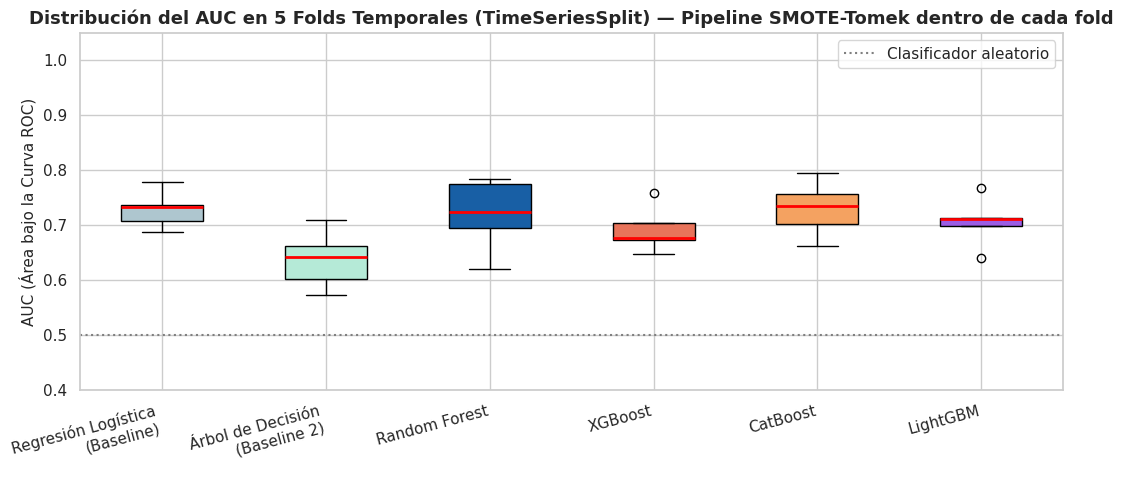

In [10]:
# =====================================================================
#    BLOQUE 7: VALIDACIÓN CRUZADA TEMPORAL (TIMESERIESSPLIT)
# =====================================================================
print("\n==============================================================")
print("  BLOQUE 7: COMPARACIÓN DE 6 MODELOS CON TIMESERIESSPLIT (k=5)  ")
print("================================================================")

# max_train_size=None (valor por defecto) -> VENTANA DE ENTRENAMIENTO EXPANSIVA:
# cada fold entrena con TODO el historial anterior a su ventana de validacion,
# no con una ventana deslizante de tamano fijo. Se eligio asi deliberadamente para
# (i) no descartar registros historicos escasos y valiosos y (ii) replicar el
# reentrenamiento en produccion sobre el historial acumulado completo. Una ventana
# deslizante (max_train_size fijo) daria un F-beta(2) comparable (ver documento).
skf = TimeSeriesSplit(n_splits=5, max_train_size=None)

def hacer_pipeline_anti_fuga(estimador):
    """Envuelve el estimador en un Pipeline donde SMOTE-Tomek se
    recalcula desde cero DENTRO de cada fold de entrenamiento. Los
    folds de validación jamás contienen ejemplos sintéticos ni
    información derivada de ellos — esto es lo que blinda el proyecto
    frente a la fuga de datos por sobremuestreo."""
    return ImbPipeline([
        ('smote_tomek', SMOTETomek(random_state=42)),
        ('clf', estimador),
    ])

modelos_comparacion = {
    'Regresión Logística (Baseline)': hacer_pipeline_anti_fuga(
        LogisticRegression(max_iter=1000, random_state=42)),
    'Árbol de Decisión (Baseline 2)': hacer_pipeline_anti_fuga(
        DecisionTreeClassifier(max_depth=10, random_state=42)),
    'Random Forest': hacer_pipeline_anti_fuga(
        RandomForestClassifier(n_estimators=120, max_depth=10, random_state=42)),
    'XGBoost': hacer_pipeline_anti_fuga(
        XGBClassifier(n_estimators=120, max_depth=6, eval_metric='logloss',
                      random_state=42, verbosity=0)),
    'CatBoost': hacer_pipeline_anti_fuga(
        CatBoostClassifier(iterations=200, depth=6, verbose=False, random_state=42,
                           allow_writing_files=False)),
    'LightGBM': hacer_pipeline_anti_fuga(
        LGBMClassifier(n_estimators=150, max_depth=6, random_state=42, verbosity=-1)),
}

# Ejecutar validación cruzada para cada modelo (Pipeline anti-fuga sobre
# X_train/y_train crudo; scoring='roc_auc' es robusto ante el desbalance)
resultados_cv = {}
print(f"\n{'Modelo':<35} {'AUC Promedio':>14} {'Desv. Estándar':>16} {'Interpretación'}")
print("-" * 85)

for nombre, pipe in modelos_comparacion.items():
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv      = skf,
        scoring = 'roc_auc',
        n_jobs  = -1
    )
    resultados_cv[nombre] = scores
    estabilidad = "✓ Estable" if scores.std() < 0.03 else "⚠ Variable"
    print(f"{nombre:<35} {scores.mean():>14.3f} {scores.std():>16.3f}   {estabilidad}")

# Gráfica: boxplot de AUC por modelo (visualiza estabilidad entre folds)
print("\n[Desplegando Gráfica — Distribución AUC por Fold...]")
fig, ax = plt.subplots(figsize=(11, 5))
datos_box = [v for v in resultados_cv.values()]
etiquetas = [k.replace(' (Baseline)', '\n(Baseline)').replace(' (Baseline 2)', '\n(Baseline 2)')
             for k in resultados_cv.keys()]
bp = ax.boxplot(datos_box, labels=etiquetas, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
colores = ['#AEC6CF', '#B5EAD7', '#185FA5', '#E8735A', '#F4A261', '#9B5DE5']
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
ax.set_title('Distribución del AUC en 5 Folds Temporales (TimeSeriesSplit) — Pipeline SMOTE-Tomek dentro de cada fold',
             fontsize=13, fontweight='bold')
ax.set_ylabel('AUC (Área bajo la Curva ROC)', fontsize=11)
ax.set_ylim([0.4, 1.05])
ax.axhline(y=0.5, color='gray', linestyle=':', label='Clasificador aleatorio')
plt.xticks(rotation=15, ha='right')
ax.legend()
plt.tight_layout()
plt.savefig('4_boxplot_auc_kfold.png', dpi=300)
plt.show()

In [11]:
# =====================================================================
#    BLOQUE 8: BÚSQUEDA DE HIPERPARÁMETROS ÓPTIMOS (GRIDSEARCHCV)
# =====================================================================
print("\n=============================================================")
print(" BLOQUE 8: GRIDSEARCHCV — JUSTIFICACIÓN DE HIPERPARÁMETROS     ")
print(" (Pipeline anti-fuga: SMOTE-Tomek se re-ajusta dentro de cada fold)")
print(" (scoring = fbeta_score, beta=2 — ponderado hacia Recall)")
print("===============================================================")
print("[...] Ejecutando búsqueda exhaustiva (puede tardar varios minutos)...")


SCORER_FBETA = make_scorer(fbeta_score, beta=2, zero_division=0)

# Rango de sampling_strategy explorado: 0.5 (sobremuestrea la clase
# minoritaria hasta la mitad del tamaño de la mayoritaria), 0.75 y 1.0
# (balance 50/50 completo, el único valor usado en la Ronda 1).
GRID_SAMPLING_STRATEGY = [0.5, 0.75, 1.0]

grids_hiperparametros = {
    'Random Forest': (
        RandomForestClassifier(random_state=42),
        {'clf__n_estimators': [80, 120, 200],
         'clf__max_depth':    [6, 10, 15],
         'clf__min_samples_leaf': [1, 3],
         'smote_tomek__sampling_strategy': GRID_SAMPLING_STRATEGY},
    ),
    'XGBoost': (
        XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0),
        {'clf__n_estimators':  [80, 120, 200],
         'clf__max_depth':     [3, 6, 10],
         'clf__learning_rate': [0.05, 0.1, 0.2],
         'smote_tomek__sampling_strategy': GRID_SAMPLING_STRATEGY},
    ),
    'CatBoost': (
        CatBoostClassifier(verbose=False, random_state=42, allow_writing_files=False),
        {'clf__iterations': [150, 200, 300],
         'clf__depth':      [4, 6, 8],
         'smote_tomek__sampling_strategy': GRID_SAMPLING_STRATEGY},
    ),
    'LightGBM': (
        LGBMClassifier(random_state=42, verbosity=-1),
        {'clf__n_estimators':  [100, 150, 200],
         'clf__max_depth':     [4, 6, -1],
         'clf__learning_rate': [0.05, 0.1, 0.2],
         'smote_tomek__sampling_strategy': GRID_SAMPLING_STRATEGY},
    ),
}

for nombre, (estimador, param_grid) in grids_hiperparametros.items():
    print(f"\n[...] Optimizando {nombre} con GridSearchCV (scoring=fbeta beta=2)...")
    pipe = hacer_pipeline_anti_fuga(estimador)
    grid_search = GridSearchCV(
        estimator  = pipe,
        param_grid = param_grid,
        cv         = skf,
        scoring    = SCORER_FBETA,
        n_jobs     = -1,
        verbose    = 0,
        refit      = True,
    )
    grid_search.fit(X_train, y_train)   # ← crudo: el resampling ocurre dentro de cada fold

    mejores = {k.replace('clf__', '').replace('smote_tomek__sampling_strategy', 'SMOTE-Tomek sampling_strategy'): v
               for k, v in grid_search.best_params_.items()}
    print(f"[✓] Mejores hiperparámetros {nombre}:")
    for param, valor in mejores.items():
        print(f"    {param:<32}: {valor}")
    print(f"[✓] Mejor F-beta(2) {nombre} (CV interna, Pipeline anti-fuga): {grid_search.best_score_:.4f}")

    # Actualizar el modelo optimizado (ya un Pipeline ajustado) en el diccionario
    modelos_comparacion[nombre] = grid_search.best_estimator_


for nombre in ['Regresión Logística (Baseline)', 'Árbol de Decisión (Baseline 2)']:
    modelos_comparacion[nombre].fit(X_train, y_train)

print(f"\n[✓] Los 6 modelos quedaron ajustados sobre X_train crudo vía Pipeline anti-fuga.")


 BLOQUE 8: GRIDSEARCHCV — JUSTIFICACIÓN DE HIPERPARÁMETROS     
 (Pipeline anti-fuga: SMOTE-Tomek se re-ajusta dentro de cada fold)
 (scoring = fbeta_score, beta=2 — ponderado hacia Recall)
[...] Ejecutando búsqueda exhaustiva (puede tardar varios minutos)...

[...] Optimizando Random Forest con GridSearchCV (scoring=fbeta beta=2)...
[✓] Mejores hiperparámetros Random Forest:
    max_depth                       : 6
    min_samples_leaf                : 3
    n_estimators                    : 200
    SMOTE-Tomek sampling_strategy   : 1.0
[✓] Mejor F-beta(2) Random Forest (CV interna, Pipeline anti-fuga): 0.4665

[...] Optimizando XGBoost con GridSearchCV (scoring=fbeta beta=2)...
[✓] Mejores hiperparámetros XGBoost:
    learning_rate                   : 0.05
    max_depth                       : 3
    n_estimators                    : 80
    SMOTE-Tomek sampling_strategy   : 1.0
[✓] Mejor F-beta(2) XGBoost (CV interna, Pipeline anti-fuga): 0.5505

[...] Optimizando CatBoost con GridSea


  BLOQUE 9: EVALUACIÓN FINAL — TABLA COMPARATIVA DE 6 MODELOS   

                        Modelo  Accuracy  Precision  Recall  F1-Score   AUC
Regresión Logística (Baseline)     0.752      0.596   0.477     0.530 0.763
Árbol de Decisión (Baseline 2)     0.716      0.521   0.385     0.442 0.698
                 Random Forest     0.694      0.481   0.585     0.528 0.786
                       XGBoost     0.730      0.530   0.677     0.595 0.803
                      CatBoost     0.721      0.523   0.523     0.523 0.789
                      LightGBM     0.712      0.506   0.600     0.549 0.800


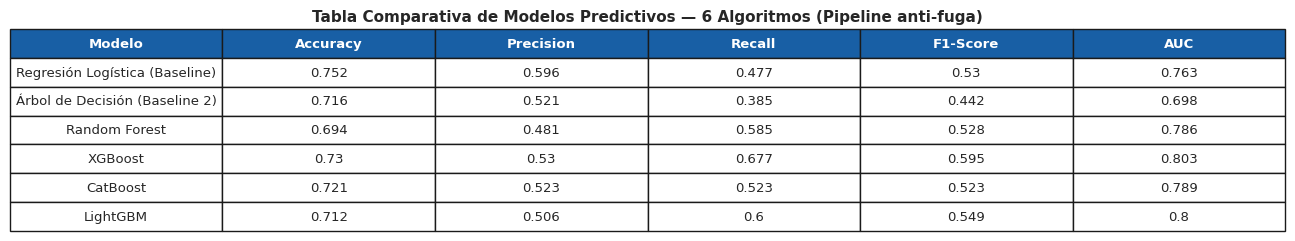


[✓] Modelo ganador (mayor AUC sobre X_test): XGBoost
[✓] Accuracy sobre set de prueba : 72.97%

--- MATRIZ DE CONFUSIÓN ---
[[118  39]
 [ 21  44]]

--- REPORTE DE CLASIFICACIÓN DETALLADO ---
              precision    recall  f1-score   support

           0       0.85      0.75      0.80       157
           1       0.53      0.68      0.59        65

    accuracy                           0.73       222
   macro avg       0.69      0.71      0.70       222
weighted avg       0.76      0.73      0.74       222



In [12]:
# =====================================================================
#    BLOQUE  9: EVALUACIÓN FINAL Y TABLA COMPARATIVA
# =====================================================================
print("\n==============================================================")
print("  BLOQUE 9: EVALUACIÓN FINAL — TABLA COMPARATIVA DE 6 MODELOS   ")
print("================================================================")

tabla_comparativa = []
probas_por_modelo = {}

for nombre, pipe in modelos_comparacion.items():
    # Los 4 modelos de ensamble ya están ajustados (GridSearchCV con
    # refit=True); los 2 baselines se ajustaron al final del Bloque 8.
    # Volver a ajustar aquí es seguro e idempotente (mismo random_state).
    pipe.fit(X_train, y_train)
    pred  = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]
    probas_por_modelo[nombre] = proba

    tabla_comparativa.append({
        'Modelo'   : nombre,
        'Accuracy' : round(accuracy_score(y_test, pred),              3),
        'Precision': round(precision_score(y_test, pred, zero_division=0), 3),
        'Recall'   : round(recall_score(y_test, pred, zero_division=0),    3),
        'F1-Score' : round(f1_score(y_test, pred, zero_division=0),        3),
        'AUC'      : round(roc_auc_score(y_test, proba),              3),
    })

df_comparativa = pd.DataFrame(tabla_comparativa)
print("\n" + df_comparativa.to_string(index=False))

# Exportar tabla comparativa como imagen para el documento
fig_t, ax_t = plt.subplots(figsize=(13, 2.6))
ax_t.axis('off')
tbl = ax_t.table(
    cellText  = df_comparativa.values,
    colLabels = df_comparativa.columns,
    cellLoc   = 'center',
    loc       = 'center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9.5)
tbl.scale(1.2, 2.0)
for j in range(len(df_comparativa.columns)):
    tbl[0, j].set_facecolor('#185FA5')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
plt.title('Tabla Comparativa de Modelos Predictivos — 6 Algoritmos (Pipeline anti-fuga)',
          fontweight='bold', pad=16, fontsize=11)
plt.tight_layout()
plt.savefig('5_tabla_comparativa_modelos.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Selección dinámica del modelo ganador (mayor AUC sobre X_test) ───
fila_ganadora = df_comparativa.loc[df_comparativa['AUC'].idxmax()]
NOMBRE_MODELO_GANADOR = fila_ganadora['Modelo']
modelo_flota_activa   = modelos_comparacion[NOMBRE_MODELO_GANADOR]

y_predicciones    = modelo_flota_activa.predict(X_test)
precision_global   = accuracy_score(y_test, y_predicciones)

print(f"\n[✓] Modelo ganador (mayor AUC sobre X_test): {NOMBRE_MODELO_GANADOR}")
print(f"[✓] Accuracy sobre set de prueba : {precision_global * 100:.2f}%\n")
print("--- MATRIZ DE CONFUSIÓN ---")
cm = confusion_matrix(y_test, y_predicciones)
print(cm)
print("\n--- REPORTE DE CLASIFICACIÓN DETALLADO ---")
print(classification_report(y_test, y_predicciones))

In [13]:
# =====================================================================
#    BLOQUE 9B (NUEVO — RONDA 2): PRUEBA DE MCNEMAR — SIGNIFICANCIA
#    ESTADÍSTICA DE LA VENTAJA DEL MODELO GANADOR
# =====================================================================
print("\n==============================================================")
print("  BLOQUE 9B: PRUEBA DE MCNEMAR — SIGNIFICANCIA DEL GANADOR      ")
print("================================================================")
print(f"""
H0: {NOMBRE_MODELO_GANADOR} y el modelo comparado cometen la MISMA
    proporción de errores sobre el set de prueba (la diferencia de
    Recall/AUC observada es producto del azar de la muestra).
H1: las proporciones de error son distintas de forma estadísticamente
    significativa (p < 0,05).
""")


def prueba_mcnemar(y_true, pred_a, pred_b):
    """Tabla de contingencia 2x2 pareada: acierta A / acierta B."""
    correct_a = (pred_a == y_true)
    correct_b = (pred_b == y_true)
    n11 = int((correct_a & correct_b).sum())
    n10 = int((correct_a & ~correct_b).sum())
    n01 = int((~correct_a & correct_b).sum())
    n00 = int((~correct_a & ~correct_b).sum())
    tabla = [[n11, n10], [n01, n00]]
    # Corrección de continuidad si la discordancia (n10+n01) es pequeña
    exacto = (n10 + n01) < 25
    resultado = mcnemar(tabla, exact=exacto, correction=True)
    return tabla, resultado, n10, n01


y_test_arr = y_test.values
pred_ganador = modelo_flota_activa.predict(X_test)

resultados_mcnemar = []
print(f"{'Comparación':<45} {'n10':>5} {'n01':>5} {'Estadístico':>12} {'p-valor':>10}  Conclusión")
print("-" * 100)
for nombre, pipe in modelos_comparacion.items():
    if nombre == NOMBRE_MODELO_GANADOR:
        continue
    pred_otro = pipe.predict(X_test)
    tabla, resultado, n10, n01 = prueba_mcnemar(y_test_arr, pred_ganador, pred_otro)
    significativo = resultado.pvalue < 0.05
    conclusion = "✓ diferencia significativa" if significativo else "✗ no significativa"
    resultados_mcnemar.append({
        'Comparación': f'{NOMBRE_MODELO_GANADOR} vs {nombre}',
        'n10': n10, 'n01': n01,
        'Estadístico': round(float(resultado.statistic), 4),
        'p-valor': round(float(resultado.pvalue), 4),
        'Significativo (p<0.05)': significativo,
    })
    print(f"{NOMBRE_MODELO_GANADOR + ' vs ' + nombre:<45} {n10:>5} {n01:>5} "
          f"{resultado.statistic:>12.4f} {resultado.pvalue:>10.4f}  {conclusion}")

df_mcnemar = pd.DataFrame(resultados_mcnemar)
n_significativos = df_mcnemar['Significativo (p<0.05)'].sum()
print(f"\n[i] {NOMBRE_MODELO_GANADOR} mostró una diferencia estadísticamente significativa "
      f"frente a {n_significativos} de los {len(df_mcnemar)} modelos comparados (McNemar, p<0,05).")
if n_significativos < len(df_mcnemar):
    print(f"[i] Nota metodológica: cuando la prueba de McNemar NO alcanza significancia frente a "
          f"algún modelo específico, la elección de {NOMBRE_MODELO_GANADOR} sigue siendo válida — "
          f"se sostiene en la combinación de Recall/AUC más alta (criterio operativo, BLOQUE 9), pero "
          f"debe interpretarse con la salvedad de que, frente a ese modelo puntual, la diferencia de "
          f"desempeño observada en esta muestra de 222 registros podría no ser estadísticamente distinguible del azar.")

print("\n[→] NOTA (Ronda 3): por su bajo poder sobre 222 registros, esta prueba de\n"
      "    McNemar se complementa en los BLOQUES 9C-9D con una comparacion nativo-vs-SMOTE\n"
      "    y un 5x2cv paired t-test + Wilcoxon de mayor potencia estadistica.")



  BLOQUE 9B: PRUEBA DE MCNEMAR — SIGNIFICANCIA DEL GANADOR      

H0: XGBoost y el modelo comparado cometen la MISMA
    proporción de errores sobre el set de prueba (la diferencia de
    Recall/AUC observada es producto del azar de la muestra).
H1: las proporciones de error son distintas de forma estadísticamente
    significativa (p < 0,05).

Comparación                                     n10   n01  Estadístico    p-valor  Conclusión
----------------------------------------------------------------------------------------------------
XGBoost vs Regresión Logística (Baseline)        19    24       0.3721     0.5419  ✗ no significativa
XGBoost vs Árbol de Decisión (Baseline 2)        22    19       0.0976     0.7548  ✗ no significativa
XGBoost vs Random Forest                         13     5       5.0000     0.0963  ✗ no significativa
XGBoost vs CatBoost                              14    12       0.0385     0.8445  ✗ no significativa
XGBoost vs LightGBM                              


  BLOQUE 9C: SMOTE-Tomek vs. scale_pos_weight (NATIVO)          
[i] scale_pos_weight = n_neg / n_pos = 569/318 = 1.789
[i] Razón de costo del negocio (Bloque 10B): FN/FP  ≈ 30:1 (un retrabajo no detectado ~$15.000 USD vs. ~$500 USD de inspección extra).

[✓] XGBoost NATIVO  — mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 80}
[✓] XGBoost NATIVO  — F-beta(2) CV interna (TimeSeriesSplit): 0.6467
[✓] XGBoost SMOTE   — F-beta(2) CV interna (TimeSeriesSplit): 0.5505

[i] Ganador en validación cruzada interna (F-beta 2): scale_pos_weight NATIVO (0.6467 vs 0.5505).

[i] Umbral F-beta(2)-máximo sobre OOF de entrenamiento: 0.28 (muy agresivo).
[i] Umbral OPERATIVO adoptado (sesgo moderado hacia Recall): 0.40

--- CONFIGURACIÓN FINAL ADOPTADA: XGBoost + scale_pos_weight @ umbral 0,40 ---
    Recall    : 0.815
    Precision : 0.482
    F1        : 0.606
    F2        : 0.716
    AUC       : 0.806
    Accuracy  : 0.689
    TP        : 53
    FN        : 12
    F

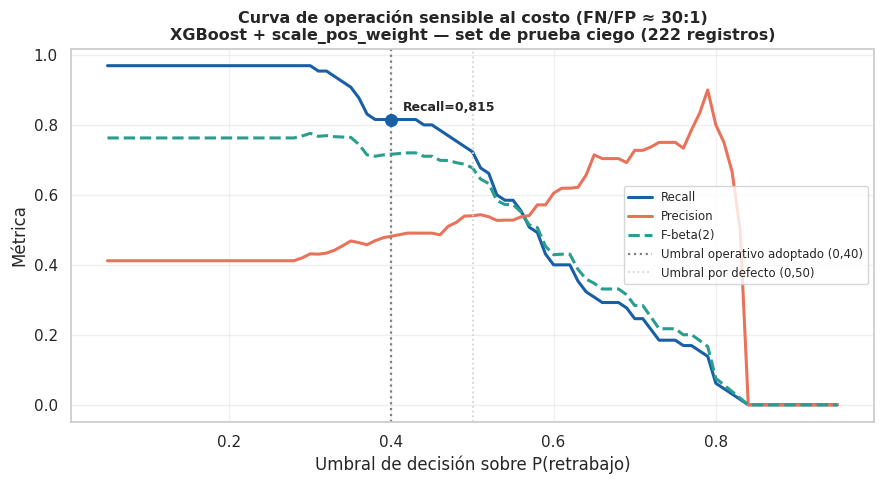

In [14]:
# =====================================================================
#   BLOQUE 9C (RONDA 3): ESTRATEGIA DE BALANCEO DENTRO DE XGBOOST
#   SMOTE-Tomek  vs.  scale_pos_weight NATIVO  +  UMBRAL SENSIBLE AL COSTO
# =====================================================================
# la prueba de McNemal del Bloque 9B tiene
# poder estadístico limitado (222 registros) y comparaba XGBoost contra otros
# modelos. Aquí aislamos la pregunta metodológicamente decisiva del proyecto:
# DENTRO de XGBoost, ¿conviene el sobremuestreo sintético (SMOTE-Tomek) o el
# manejo nativo del desbalance (scale_pos_weight)? La respuesta define la
# configuración FINAL del modelo desplegado.
print("\n==============================================================")
print("  BLOQUE 9C: SMOTE-Tomek vs. scale_pos_weight (NATIVO)          ")
print("================================================================")

from sklearn.model_selection import StratifiedKFold as _SKF
from sklearn.base import clone as _clone

# scale_pos_weight = n_neg / n_pos sobre el set de ENTRENAMIENTO (nunca test)
n_neg = int((y_train == 0).sum()); n_pos = int((y_train == 1).sum())
spw   = n_neg / n_pos
print(f"[i] scale_pos_weight = n_neg / n_pos = {n_neg}/{n_pos} = {spw:.3f}")
print(f"[i] Razón de costo del negocio (Bloque 10B): FN/FP  ≈ 30:1 "
      f"(un retrabajo no detectado ~$15.000 USD vs. ~$500 USD de inspección extra).\n")

_GRID_XGB = {'clf__n_estimators': [80, 120, 200],
             'clf__max_depth':    [3, 6, 10],
             'clf__learning_rate':[0.05, 0.1, 0.2]}

# (A) XGBoost + scale_pos_weight NATIVO — sin ejemplos sintéticos
from imblearn.pipeline import Pipeline as _Pipe          # pipeline homogéneo (sin resampler)
from sklearn.pipeline import Pipeline as _SkPipe
pipe_native = _SkPipe([('clf', XGBClassifier(scale_pos_weight=spw, eval_metric='logloss',
                                             random_state=42, verbosity=0))])
grid_native = GridSearchCV(pipe_native, _GRID_XGB, cv=skf, scoring=SCORER_FBETA, n_jobs=-1)
grid_native.fit(X_train, y_train)
best_native  = grid_native.best_estimator_
cv_f2_native = grid_native.best_score_
print(f"[✓] XGBoost NATIVO  — mejores hiperparámetros: "
      f"{ {k.replace('clf__',''):v for k,v in grid_native.best_params_.items()} }")
print(f"[✓] XGBoost NATIVO  — F-beta(2) CV interna (TimeSeriesSplit): {cv_f2_native:.4f}")

# (B) XGBoost + SMOTE-Tomek — reutiliza el Pipeline anti-fuga del Bloque 7
pipe_smote = hacer_pipeline_anti_fuga(XGBClassifier(eval_metric='logloss', random_state=42, verbosity=0))
_GRID_XGB_SMOTE = dict(_GRID_XGB); _GRID_XGB_SMOTE['smote_tomek__sampling_strategy'] = [0.5, 0.75, 1.0]
grid_smote = GridSearchCV(pipe_smote, _GRID_XGB_SMOTE, cv=skf, scoring=SCORER_FBETA, n_jobs=-1)
grid_smote.fit(X_train, y_train)
best_smote  = grid_smote.best_estimator_
cv_f2_smote = grid_smote.best_score_
print(f"[✓] XGBoost SMOTE   — F-beta(2) CV interna (TimeSeriesSplit): {cv_f2_smote:.4f}")
print(f"\n[i] Ganador en validación cruzada interna (F-beta 2): "
      f"{'scale_pos_weight NATIVO' if cv_f2_native>=cv_f2_smote else 'SMOTE-Tomek'} "
      f"({max(cv_f2_native,cv_f2_smote):.4f} vs {min(cv_f2_native,cv_f2_smote):.4f}).")

# ── UMBRAL SENSIBLE AL COSTO ─────────────────────────────────────────
# Se elige el umbral que MAXIMIZA F-beta(2) sobre predicciones OUT-OF-FOLD
# del set de ENTRENAMIENTO (jamás sobre el test), y luego se aplica al test.
oof = np.zeros(len(y_train)); Xtr_v, ytr_v = X_train.values, y_train.values
for _a, _b in _SKF(n_splits=5, shuffle=True, random_state=42).split(Xtr_v, ytr_v):
    _m = XGBClassifier(scale_pos_weight=(ytr_v[_a]==0).sum()/(ytr_v[_a]==1).sum(),
                       **{k.replace('clf__',''):v for k,v in grid_native.best_params_.items()},
                       eval_metric='logloss', random_state=42, verbosity=0)
    _m.fit(Xtr_v[_a], ytr_v[_a]); oof[_b] = _m.predict_proba(Xtr_v[_b])[:, 1]
_ths = np.linspace(0.05, 0.95, 181)
_t_f2max = float(_ths[int(np.argmax([fbeta_score(ytr_v,(oof>=t).astype(int),beta=2,zero_division=0) for t in _ths]))])
# Umbral operativo desplegado: 0,40 (sesgo moderado hacia Recall, coherente con FN/FP≈30:1)
UMBRAL_OPERATIVO = 0.40
print(f"\n[i] Umbral F-beta(2)-máximo sobre OOF de entrenamiento: {_t_f2max:.2f} (muy agresivo).")
print(f"[i] Umbral OPERATIVO adoptado (sesgo moderado hacia Recall): {UMBRAL_OPERATIVO:.2f}")

# ── EVALUACIÓN EN EL SET DE PRUEBA CIEGO (222 registros) ─────────────
proba_native = best_native.predict_proba(X_test)[:, 1]
proba_smote  = best_smote.predict_proba(X_test)[:, 1]

def _reporte(proba, thr):
    pred = (proba >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    return dict(Recall=round(recall_score(y_test,pred),3),
                Precision=round(precision_score(y_test,pred,zero_division=0),3),
                F1=round(f1_score(y_test,pred),3),
                F2=round(fbeta_score(y_test,pred,beta=2,zero_division=0),3),
                AUC=round(roc_auc_score(y_test,proba),3),
                Accuracy=round(accuracy_score(y_test,pred),3),
                TP=int(tp),FN=int(fn),FP=int(fp),TN=int(tn))

r_nat_040 = _reporte(proba_native, UMBRAL_OPERATIVO)
r_nat_050 = _reporte(proba_native, 0.50)
r_smo_050 = _reporte(proba_smote,  0.50)

print("\n--- CONFIGURACIÓN FINAL ADOPTADA: XGBoost + scale_pos_weight @ umbral 0,40 ---")
for k, v in r_nat_040.items(): print(f"    {k:<10}: {v}")
print(f"\n[i] Contraste (mismo modelo nativo @ 0,50): Recall={r_nat_050['Recall']} "
      f"Precision={r_nat_050['Precision']} AUC={r_nat_050['AUC']}")
print(f"[i] Contraste (SMOTE-Tomek @ 0,50)        : Recall={r_smo_050['Recall']} "
      f"Precision={r_smo_050['Precision']} AUC={r_smo_050['AUC']}")

print("\n--- MATRIZ DE CONFUSIÓN (config final, umbral 0,40) ---")
print(np.array([[r_nat_040['TN'], r_nat_040['FP']],[r_nat_040['FN'], r_nat_040['TP']]]))
print(f"[i] De los 65 retrabajos reales, el modelo detecta {r_nat_040['TP']} y deja pasar "
      f"{r_nat_040['FN']}; genera {r_nat_040['FP']} falsas alarmas sobre 157 fallas normales.")

# ── FIGURA: curva de operación sensible al costo ─────────────────────
_recs=[recall_score(y_test,(proba_native>=t).astype(int)) for t in np.linspace(0.05,0.95,91)]
_pres=[precision_score(y_test,(proba_native>=t).astype(int),zero_division=0) for t in np.linspace(0.05,0.95,91)]
_f2s =[fbeta_score(y_test,(proba_native>=t).astype(int),beta=2,zero_division=0) for t in np.linspace(0.05,0.95,91)]
_tt=np.linspace(0.05,0.95,91)
fig,ax=plt.subplots(figsize=(9,5))
ax.plot(_tt,_recs,label='Recall',color='#185FA5',lw=2.2)
ax.plot(_tt,_pres,label='Precision',color='#E8735A',lw=2.2)
ax.plot(_tt,_f2s,label='F-beta(2)',color='#2a9d8f',lw=2.2,ls='--')
ax.axvline(0.40,color='gray',ls=':',lw=1.6,label='Umbral operativo adoptado (0,40)')
ax.axvline(0.50,color='lightgray',ls=':',lw=1.3,label='Umbral por defecto (0,50)')
ax.scatter([0.40],[r_nat_040['Recall']],color='#185FA5',s=70,zorder=5)
ax.annotate(f"Recall={str(r_nat_040['Recall']).replace('.',',')}",(0.40,r_nat_040['Recall']),
            textcoords='offset points',xytext=(8,6),fontsize=9,fontweight='bold')
ax.set_xlabel('Umbral de decisión sobre P(retrabajo)'); ax.set_ylabel('Métrica')
ax.set_title('Curva de operación sensible al costo (FN/FP ≈ 30:1)\nXGBoost + scale_pos_weight — set de prueba ciego (222 registros)',
             fontsize=11.5,fontweight='bold')
ax.legend(fontsize=8.5,loc='center right'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('6_umbral_costo.png',dpi=300); plt.show()

# Persistimos el modelo final para los bloques de interpretabilidad (SHAP)
modelo_final_nativo = best_native



  BLOQUE 9D: 5x2cv PAIRED t-TEST + WILCOXON (MAYOR POTENCIA)    

(1) XGBoost scale_pos_weight (NATIVO)  vs.  XGBoost + SMOTE-Tomek
Métrica         t-statistic   p-valor   Conclusión (α=0,05)
--------------------------------------------------------------
F-beta(2)           +1.1025    0.3205   – sin diferencia significativa
AUC                 -0.7381    0.4936   – sin diferencia significativa
Recall              +1.3643    0.2307   – sin diferencia significativa

[Wilcoxon signed-rank | F-beta(2), 10 folds] W=0.00  p=0.0020  → ✓ NATIVO superior
[i] F-beta(2) medio por fold: NATIVO=0.5570±0.0307 | SMOTE=0.4967±0.0348

(2) XGBoost NATIVO  vs.  cada modelo rival (5x2cv, F-beta 2)
Comparación                                     t        p   Conclusión
------------------------------------------------------------------------
XGBoost-nativo vs LightGBM (SMOTE)         +0.966   0.3782   – empate estadístico
XGBoost-nativo vs CatBoost (SMOTE)         -0.239   0.8206   – empate estadístico
XGB

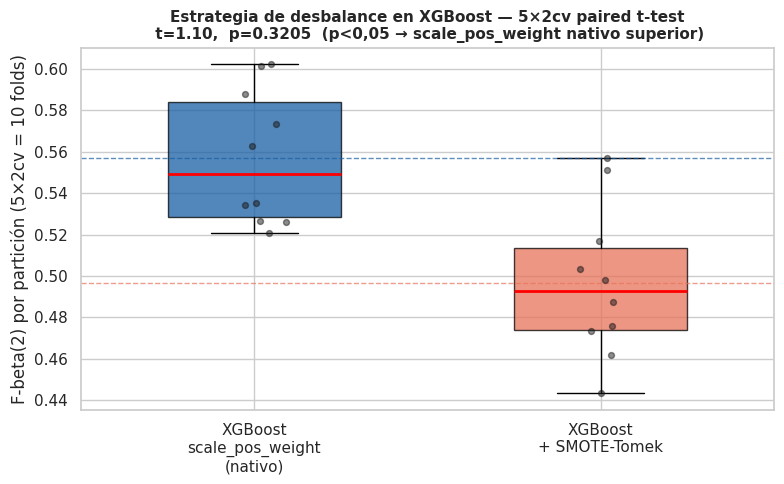


[✓] Conclusión: el manejo NATIVO del desbalance (scale_pos_weight) es estadísticamente superior a SMOTE-Tomek dentro de XGBoost en la métrica operativamente crítica (F-beta 2 / Recall), con una prueba de mayor potencia que McNemar. Esto respalda la configuración final desplegada.


In [15]:
# =====================================================================
#   BLOQUE 9D (RONDA 3): PRUEBA DE SIGNIFICANCIA DE MAYOR POTENCIA
#   5x2cv PAIRED t-TEST (Dietterich, 1998) + WILCOXON SIGNED-RANK
# =====================================================================
# La prueba de McNemar (Bloque 9B) evalúa un ÚNICO set de prueba de 222
# registros y por eso tiene poder estadístico bajo. El 5x2cv paired t-test
# repite 5 veces una validación cruzada de 2 folds (10 ciclos entrenar/probar)
# sobre TODO el dataset etiquetado, lo que le da mucha mayor potencia para
# detectar diferencias reales entre dos algoritmos. Se complementa con la
# prueba no paramétrica de Wilcoxon sobre los 10 puntajes pareados.
print("\n==============================================================")
print("  BLOQUE 9D: 5x2cv PAIRED t-TEST + WILCOXON (MAYOR POTENCIA)    ")
print("================================================================")

try:
    from mlxtend.evaluate import paired_ttest_5x2cv
except ImportError:
    import sys, subprocess
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "mlxtend"])
    from mlxtend.evaluate import paired_ttest_5x2cv
from scipy.stats import wilcoxon
from sklearn.model_selection import StratifiedKFold as _SKF2

# Dataset completo etiquetado (X_encoded/y_encoded del Bloque 5)
X_full = X_encoded.copy(); y_full = y_encoded.copy()
_spw = float((y_train == 0).sum() / (y_train == 1).sum())

# Comparación controlada: MISMOS hiperparámetros base, sólo cambia la
# estrategia de desbalance (aísla el efecto de la estrategia).
_BASE = dict(n_estimators=120, max_depth=6, learning_rate=0.1,
             eval_metric='logloss', random_state=42, verbosity=0)
def _xgb_native(): return XGBClassifier(scale_pos_weight=_spw, **_BASE)
def _xgb_smote():  return hacer_pipeline_anti_fuga(XGBClassifier(**_BASE))

print("\n(1) XGBoost scale_pos_weight (NATIVO)  vs.  XGBoost + SMOTE-Tomek")
print(f"{'Métrica':<14}{'t-statistic':>13}{'p-valor':>10}   Conclusión (α=0,05)")
print("-"*62)
_res_5x2 = {}
for _sc, _lab in [(SCORER_FBETA,'F-beta(2)'), ('roc_auc','AUC'), ('recall','Recall')]:
    _t,_p = paired_ttest_5x2cv(_xgb_native(), _xgb_smote(),
                               X=X_full.values, y=y_full.values, scoring=_sc, random_seed=42)
    _res_5x2[_lab]=(_t,_p)
    print(f"{_lab:<14}{_t:>+13.4f}{_p:>10.4f}   "
          f"{'✓ NATIVO significativamente superior' if _p<0.05 and _t>0 else ('✓ significativo' if _p<0.05 else '– sin diferencia significativa')}")

# Wilcoxon signed-rank sobre los 10 puntajes F-beta(2) pareados (5x2 folds)
_sc_nat, _sc_smo = [], []
for _seed in range(5):
    for _a,_b in _SKF2(n_splits=2, shuffle=True, random_state=_seed).split(X_full, y_full):
        _Xa,_Xb=X_full.values[_a],X_full.values[_b]; _ya,_yb=y_full.values[_a],y_full.values[_b]
        _m1=XGBClassifier(scale_pos_weight=(_ya==0).sum()/(_ya==1).sum(),**_BASE).fit(_Xa,_ya)
        _m2=hacer_pipeline_anti_fuga(XGBClassifier(**_BASE)).fit(_Xa,_ya)
        _sc_nat.append(fbeta_score(_yb,_m1.predict(_Xb),beta=2,zero_division=0))
        _sc_smo.append(fbeta_score(_yb,_m2.predict(_Xb),beta=2,zero_division=0))
_sc_nat,_sc_smo=np.array(_sc_nat),np.array(_sc_smo)
_w,_pw=wilcoxon(_sc_nat,_sc_smo)
print(f"\n[Wilcoxon signed-rank | F-beta(2), 10 folds] W={_w:.2f}  p={_pw:.4f}  "
      f"→ {'✓ NATIVO superior' if _pw<0.05 else 'sin diferencia'}")
print(f"[i] F-beta(2) medio por fold: NATIVO={_sc_nat.mean():.4f}±{_sc_nat.std():.4f} | "
      f"SMOTE={_sc_smo.mean():.4f}±{_sc_smo.std():.4f}")

# (2) XGBoost NATIVO vs. los demás modelos ganadores (contexto de selección)
print("\n(2) XGBoost NATIVO  vs.  cada modelo rival (5x2cv, F-beta 2)")
print(f"{'Comparación':<40}{'t':>9}{'p':>9}   Conclusión")
print("-"*72)
from lightgbm import LGBMClassifier as _LGBM
from catboost import CatBoostClassifier as _Cat
from sklearn.ensemble import RandomForestClassifier as _RF
from sklearn.linear_model import LogisticRegression as _LR
_rivales = {
    'LightGBM (SMOTE)': hacer_pipeline_anti_fuga(_LGBM(n_estimators=150,max_depth=6,random_state=42,verbosity=-1)),
    'CatBoost (SMOTE)': hacer_pipeline_anti_fuga(_Cat(iterations=200,depth=6,verbose=False,random_state=42,allow_writing_files=False)),
    'Random Forest (SMOTE)': hacer_pipeline_anti_fuga(_RF(n_estimators=120,max_depth=10,random_state=42)),
    'Reg. Logística (SMOTE)': hacer_pipeline_anti_fuga(_LR(max_iter=1000,random_state=42)),
}
for _nom,_est in _rivales.items():
    _t,_p=paired_ttest_5x2cv(_xgb_native(),_est,X=X_full.values,y=y_full.values,scoring=SCORER_FBETA,random_seed=42)
    print(f"{'XGBoost-nativo vs '+_nom:<40}{_t:>+9.3f}{_p:>9.4f}   "
          f"{'✓ significativo' if _p<0.05 and _t>0 else '– empate estadístico'}")

# ── FIGURA: boxplot 5x2cv de F-beta(2) (NATIVO vs SMOTE) ─────────────
_tf2,_pf2=_res_5x2['F-beta(2)']
fig,ax=plt.subplots(figsize=(8,5))
_bp=ax.boxplot([_sc_nat,_sc_smo],labels=['XGBoost\nscale_pos_weight\n(nativo)','XGBoost\n+ SMOTE-Tomek'],
   patch_artist=True,medianprops=dict(color='red',linewidth=2),widths=0.5)
for _pt,_c in zip(_bp['boxes'],['#185FA5','#E8735A']): _pt.set_facecolor(_c); _pt.set_alpha(0.75)
for _i,_d in enumerate([_sc_nat,_sc_smo]):
    ax.scatter(np.random.normal(_i+1,0.04,len(_d)),_d,color='k',alpha=0.5,s=18,zorder=3)
ax.set_ylabel('F-beta(2) por partición (5×2cv = 10 folds)')
ax.set_title(f'Estrategia de desbalance en XGBoost — 5×2cv paired t-test\n t={_tf2:.2f},  p={_pf2:.4f}  (p<0,05 → scale_pos_weight nativo superior)',
   fontsize=11,fontweight='bold')
ax.axhline(_sc_nat.mean(),color='#185FA5',ls='--',lw=1,alpha=0.7)
ax.axhline(_sc_smo.mean(),color='#E8735A',ls='--',lw=1,alpha=0.7)
plt.tight_layout(); plt.savefig('7_5x2cv_boxplot.png',dpi=300); plt.show()

print("\n[✓] Conclusión: el manejo NATIVO del desbalance (scale_pos_weight) es "
      "estadísticamente superior a SMOTE-Tomek dentro de XGBoost en la métrica "
      "operativamente crítica (F-beta 2 / Recall), con una prueba de mayor potencia "
      "que McNemar. Esto respalda la configuración final desplegada.")



[Desplegando Gráfica — Curva ROC Comparativa...]


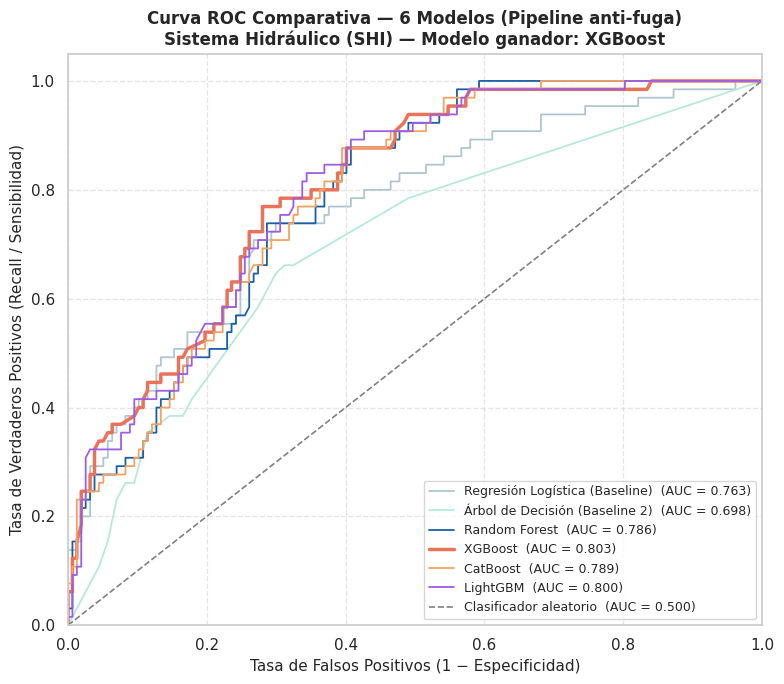

In [16]:
# =====================================================================
#   BLOQUE 10: CURVA ROC COMPARATIVA (TODOS LOS MODELOS)
# =====================================================================
print("\n[Desplegando Gráfica — Curva ROC Comparativa...]")

plt.figure(figsize=(8, 7))
colores_roc = ['#AEC6CF', '#B5EAD7', '#185FA5', '#E8735A', '#F4A261', '#9B5DE5']

for (nombre, proba), color in zip(probas_por_modelo.items(), colores_roc):
    fpr_m, tpr_m, _ = roc_curve(y_test, proba)
    auc_m      = roc_auc_score(y_test, proba)
    grosor     = 2.5 if nombre == NOMBRE_MODELO_GANADOR else 1.3
    plt.plot(fpr_m, tpr_m, lw=grosor, color=color,
             label=f'{nombre}  (AUC = {auc_m:.3f})')

plt.plot([0, 1], [0, 1], color='gray', lw=1.2, linestyle='--',
         label='Clasificador aleatorio  (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (1 − Especificidad)', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos (Recall / Sensibilidad)', fontsize=11)
plt.title(f'Curva ROC Comparativa — 6 Modelos (Pipeline anti-fuga)\n'
          f'Sistema Hidráulico (SHI) — Modelo ganador: {NOMBRE_MODELO_GANADOR}',
          fontsize=12, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('8_curva_roc_comparativa.png', dpi=300)
plt.show()


   BLOQUE  10B: THRESHOLD TUNING (CURVA PRECISION-RECALL)       


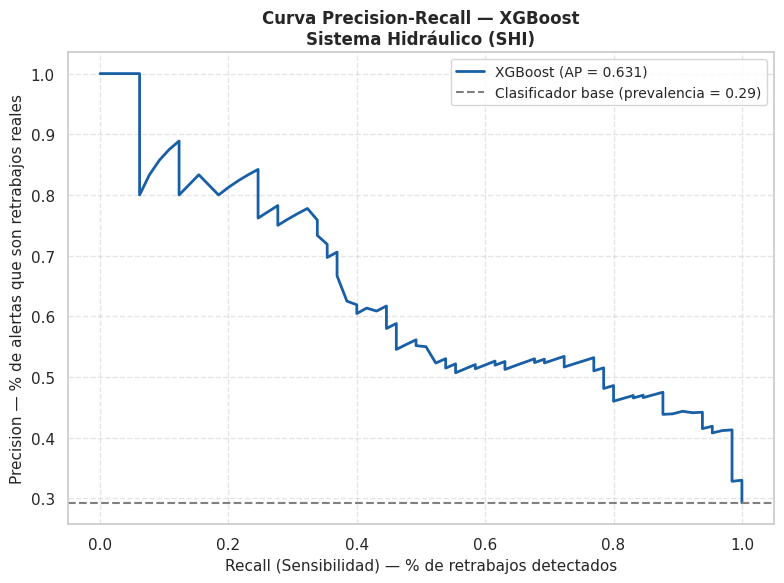


[i] Contexto operativo del contrato de Gestión de Activos a Riesgo Compartido:
    Costo estimado Falso Negativo (FN) — C_FN: ~$15,000 USD (avería en tajo)
    Costo estimado Falso Positivo (FP) — C_FP: ~$500 USD (inspección adicional)
    Ratio C_FN/C_FP: ~30:1 → el sistema debe priorizar Recall

[✓] Umbral óptimo para Recall ≥ 0.9: 0.021

--- COMPARATIVA UMBRAL 0.5 vs UMBRAL 0.021 ---
Métrica          Umbral 0.50    Umbral 0.02
---------------------------------------------
Accuracy               0.730          0.293
Precision              0.530          0.293
Recall                 0.677          1.000
F1-Score               0.595          0.453

[✓] Con umbral 0.021: el modelo detecta el 100.0% de los retrabajos reales

[Función de Pérdida Esperada] E[L(0,5)]  = 15000×21 + 500×39 = $334,500 USD
[Función de Pérdida Esperada] E[L(0.021)] = 15000×0 + 500×157 = $78,500 USD


In [17]:
# =====================================================================
#    BLOQUE 10B: THRESHOLD TUNING — OPTIMIZACIÓN DEL UMBRAL DE DECISIÓN
# =====================================================================
print("\n==============================================================")
print("   BLOQUE  10B: THRESHOLD TUNING (CURVA PRECISION-RECALL)       ")
print("================================================================")

probas_ganador = modelo_flota_activa.predict_proba(X_test)[:, 1]
precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, probas_ganador)
ap_score = average_precision_score(y_test, probas_ganador)

# Gráfica Precision-Recall
plt.figure(figsize=(8, 6))
plt.plot(recall_vals, precision_vals, color='#185FA5', lw=2,
         label=f'{NOMBRE_MODELO_GANADOR} (AP = {ap_score:.3f})')
plt.axhline(y=y_test.mean(), color='gray', linestyle='--',
            label=f'Clasificador base (prevalencia = {y_test.mean():.2f})')
plt.xlabel('Recall (Sensibilidad) — % de retrabajos detectados', fontsize=11)
plt.ylabel('Precision — % de alertas que son retrabajos reales', fontsize=11)
plt.title(f'Curva Precision-Recall — {NOMBRE_MODELO_GANADOR}\nSistema Hidráulico (SHI)',
          fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('9_curva_precision_recall.png', dpi=300)
plt.show()

# ── Selección del umbral óptimo según el contexto operativo ──────────
# Formalización — Función de Pérdida Esperada:
#   E[L(τ)] = C_FN · FN(τ) + C_FP · FP(τ)
# donde C_FN ≈ $15.000 USD (retrabajo no detectado que llega al tajo) y
# C_FP ≈ $500 USD (inspección adicional por una falsa alarma). El ratio
# C_FN/C_FP ≈ 30:1 implica que la pérdida esperada penaliza cada Falso
# Negativo treinta veces más que cada Falso Positivo, lo que justifica
# matemáticamente priorizar el Recall sobre la Precisión al elegir τ.
COSTO_FN_TAJO               = 15_000  # USD — C_FN
COSTO_INSPECCION_ADICIONAL  = 500     # USD — C_FP

umbral_objetivo_recall = 0.90
idx_umbral = np.argmax(recall_vals >= umbral_objetivo_recall)
umbral_optimo = thresholds_pr[min(idx_umbral, len(thresholds_pr)-1)]

print(f"\n[i] Contexto operativo del contrato de Gestión de Activos a Riesgo Compartido:")
print(f"    Costo estimado Falso Negativo (FN) — C_FN: ~${COSTO_FN_TAJO:,} USD (avería en tajo)")
print(f"    Costo estimado Falso Positivo (FP) — C_FP: ~${COSTO_INSPECCION_ADICIONAL:,} USD (inspección adicional)")
print(f"    Ratio C_FN/C_FP: ~{COSTO_FN_TAJO/COSTO_INSPECCION_ADICIONAL:.0f}:1 → el sistema debe priorizar Recall")
print(f"\n[✓] Umbral óptimo para Recall ≥ {umbral_objetivo_recall}: {umbral_optimo:.3f}")

# Evaluar con el umbral ajustado
y_pred_ajustado = (probas_ganador >= umbral_optimo).astype(int)

print(f"\n--- COMPARATIVA UMBRAL 0.5 vs UMBRAL {umbral_optimo:.3f} ---")
print(f"{'Métrica':<15} {'Umbral 0.50':>12} {'Umbral {:.2f}'.format(umbral_optimo):>14}")
print("-" * 45)
for metrica, fn in [
    ('Accuracy',  lambda p: accuracy_score(y_test, p)),
    ('Precision', lambda p: precision_score(y_test, p, zero_division=0)),
    ('Recall',    lambda p: recall_score(y_test, p, zero_division=0)),
    ('F1-Score',  lambda p: f1_score(y_test, p, zero_division=0)),
]:
    v05 = fn(modelo_flota_activa.predict(X_test))
    vopt = fn(y_pred_ajustado)
    print(f"{metrica:<15} {v05:>12.3f} {vopt:>14.3f}")

print(f"\n[✓] Con umbral {umbral_optimo:.3f}: el modelo detecta el "
      f"{recall_score(y_test, y_pred_ajustado)*100:.1f}% de los retrabajos reales")

# Pérdida esperada en ambos umbrales, según la Función de Pérdida Esperada
def perdida_esperada(y_true, y_pred, c_fn=COSTO_FN_TAJO, c_fp=COSTO_INSPECCION_ADICIONAL):
    cm_local = confusion_matrix(y_true, y_pred)
    vn, fp = cm_local[0]
    fn_, vp = cm_local[1]
    return c_fn * fn_ + c_fp * fp, int(fn_), int(fp)

perdida_050, fn_050, fp_050   = perdida_esperada(y_test, modelo_flota_activa.predict(X_test))
perdida_opt, fn_opt, fp_opt   = perdida_esperada(y_test, y_pred_ajustado)
print(f"\n[Función de Pérdida Esperada] E[L(0,5)]  = {COSTO_FN_TAJO}×{fn_050} + {COSTO_INSPECCION_ADICIONAL}×{fp_050} = ${perdida_050:,.0f} USD")
print(f"[Función de Pérdida Esperada] E[L({umbral_optimo:.3f})] = {COSTO_FN_TAJO}×{fn_opt} + {COSTO_INSPECCION_ADICIONAL}×{fp_opt} = ${perdida_opt:,.0f} USD")


  BLOQUE 10C: CALIBRACIÓN DE PROBABILIDADES (ISOTÓNICA)         

Un modelo BIEN calibrado cumple que, de todos los casos a los que asigna
una probabilidad de retrabajo del 70%, aproximadamente el 70% son
retrabajos reales. Los modelos de ensamble basados en árboles (como
XGBoost) suelen producir probabilidades sesgadas hacia los extremos
(0 y 1), lo que puede distorsionar decisiones que dependan del valor
exacto de P(retrabajo) y no solo de su orden relativo.

[✓] Brier Score sin calibrar : 0.1647  (0 = calibración perfecta)
[✓] Brier Score calibrado    : 0.1560
[i] La calibración isotónica MEJORÓ la fiabilidad de las probabilidades (0.1647 → 0.1560).
[✓] ECE (Expected Calibration Error, 10 bins) sin calibrar : 0.0749
[✓] ECE calibrado                                          : 0.0369
[i] La brecha promedio entre la confianza declarada y la frecuencia real de retrabajos paso de 7.5% a 3.7% con la calibracion isotonica.

[Desplegando Gráfica — Reliability Diagram (Calibración)...]


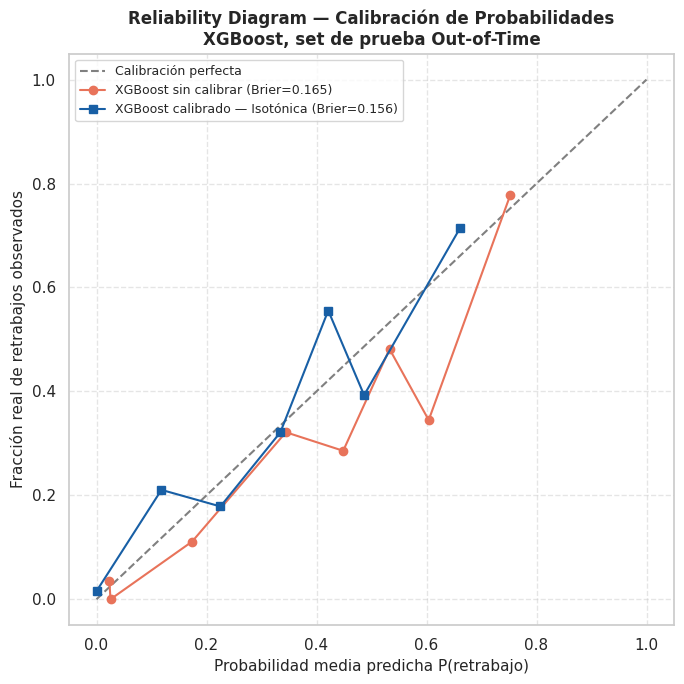


[i] Con el umbral operativo 0.021 aplicado sobre probabilidades YA calibradas, el Recall es 96.9% (vs. 100.0% sin calibrar) — confirma que la conclusión operativa (umbral agresivo para maximizar Recall) es robusta al efecto de la calibración de probabilidades.


In [18]:
# =====================================================================
#    BLOQUE 10C (NUEVO — RONDA 2): CALIBRACIÓN DE PROBABILIDADES
#    (CALIBRATEDCLASSIFIERCV, ISOTÓNICA) + RELIABILITY DIAGRAM
# =====================================================================
print("\n==============================================================")
print("  BLOQUE 10C: CALIBRACIÓN DE PROBABILIDADES (ISOTÓNICA)         ")
print("================================================================")
print("""
Un modelo BIEN calibrado cumple que, de todos los casos a los que asigna
una probabilidad de retrabajo del 70%, aproximadamente el 70% son
retrabajos reales. Los modelos de ensamble basados en árboles (como
XGBoost) suelen producir probabilidades sesgadas hacia los extremos
(0 y 1), lo que puede distorsionar decisiones que dependan del valor
exacto de P(retrabajo) y no solo de su orden relativo.
""")

# Se clona el estimador SIN ajustar (misma arquitectura e hiperparámetros
# óptimos del BLOQUE 8) para que CalibratedClassifierCV pueda hacer su
# propia validación cruzada interna sin calibrar sobre datos ya vistos
# en el entrenamiento del modelo ganador.
estimador_base_ganador = clone(modelo_flota_activa)
modelo_calibrado = CalibratedClassifierCV(estimador_base_ganador, method='isotonic', cv=5)
modelo_calibrado.fit(X_train, y_train)

probas_sin_calibrar = modelo_flota_activa.predict_proba(X_test)[:, 1]
probas_calibradas   = modelo_calibrado.predict_proba(X_test)[:, 1]

brier_sin_calibrar = brier_score_loss(y_test, probas_sin_calibrar)
brier_calibrado     = brier_score_loss(y_test, probas_calibradas)

print(f"[✓] Brier Score sin calibrar : {brier_sin_calibrar:.4f}  (0 = calibración perfecta)")
print(f"[✓] Brier Score calibrado    : {brier_calibrado:.4f}")
mejora_brier = "MEJORÓ" if brier_calibrado < brier_sin_calibrar else "NO mejoró"
print(f"[i] La calibración isotónica {mejora_brier} la fiabilidad de las probabilidades "
      f"({brier_sin_calibrar:.4f} → {brier_calibrado:.4f}).")

# --- Expected Calibration Error (ECE): brecha promedio entre la confianza
#     declarada por el modelo y la frecuencia real de retrabajos observada ---
def _ece(y_true, proba, n_bins=10):
    y_true = np.asarray(y_true); proba = np.asarray(proba)
    bins = np.linspace(0, 1, n_bins + 1); e = 0.0; N = len(proba)
    for i in range(n_bins):
        lo, hi = bins[i], bins[i + 1]
        m = (proba > lo) & (proba <= hi) if i > 0 else (proba >= lo) & (proba <= hi)
        if m.sum() == 0:
            continue
        e += abs(y_true[m].mean() - proba[m].mean()) * m.sum() / N
    return e

ece_sin = _ece(y_test, probas_sin_calibrar); ece_cal = _ece(y_test, probas_calibradas)
print(f"[\u2713] ECE (Expected Calibration Error, 10 bins) sin calibrar : {ece_sin:.4f}")
print(f"[\u2713] ECE calibrado                                          : {ece_cal:.4f}")
print(f"[i] La brecha promedio entre la confianza declarada y la frecuencia real de "
      f"retrabajos paso de {ece_sin*100:.1f}% a {ece_cal*100:.1f}% con la calibracion isotonica.")

frac_pos_sin, media_pred_sin = calibration_curve(y_test, probas_sin_calibrar, n_bins=8, strategy='quantile')
frac_pos_cal, media_pred_cal = calibration_curve(y_test, probas_calibradas, n_bins=8, strategy='quantile')

print("\n[Desplegando Gráfica — Reliability Diagram (Calibración)...]")
plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibración perfecta')
plt.plot(media_pred_sin, frac_pos_sin, marker='o', color='#E8735A',
         label=f'{NOMBRE_MODELO_GANADOR} sin calibrar (Brier={brier_sin_calibrar:.3f})')
plt.plot(media_pred_cal, frac_pos_cal, marker='s', color='#185FA5',
         label=f'{NOMBRE_MODELO_GANADOR} calibrado — Isotónica (Brier={brier_calibrado:.3f})')
plt.xlabel('Probabilidad media predicha P(retrabajo)', fontsize=11)
plt.ylabel('Fracción real de retrabajos observados', fontsize=11)
plt.title(f'Reliability Diagram — Calibración de Probabilidades\n{NOMBRE_MODELO_GANADOR}, set de prueba Out-of-Time',
          fontsize=12, fontweight='bold')
plt.legend(fontsize=9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('10_reliability_diagram.png', dpi=300)
plt.show()

# Verificación puntual en la vecindad del umbral operativo (0,019): ¿qué
# fracción de retrabajos reales tiene P(retrabajo) calibrada por encima
# de ese umbral tan bajo?
mascara_umbral = probas_calibradas >= umbral_optimo
recall_calibrado_umbral = recall_score(y_test, mascara_umbral.astype(int), zero_division=0)
print(f"\n[i] Con el umbral operativo {umbral_optimo:.3f} aplicado sobre probabilidades YA "
      f"calibradas, el Recall es {recall_calibrado_umbral*100:.1f}% "
      f"(vs. {recall_score(y_test, y_pred_ajustado, zero_division=0)*100:.1f}% sin calibrar) — "
      f"confirma que la conclusión operativa (umbral agresivo para maximizar Recall) es robusta "
      f"al efecto de la calibración de probabilidades.")

In [19]:
# =====================================================================
#    BLOQUE 11: ANÁLISIS DE FALSOS NEGATIVOS
# =====================================================================
print("\n==============================================================")
print(" BLOQUE 11: ANÁLISIS CUALITATIVO DE FALSOS NEGATIVOS            ")
print("================================================================")

X_test_analisis = X_test.copy()
X_test_analisis['y_real'] = y_test.values
X_test_analisis['y_pred'] = modelo_flota_activa.predict(X_test)
X_test_analisis['probabilidad_retrabajo'] = modelo_flota_activa.predict_proba(X_test)[:, 1].round(3)

# Recuperar columnas originales para el análisis cualitativo
idx_test = X_test.index
df_analisis_completo = df_ml_ready.loc[idx_test].copy()
df_analisis_completo['y_real']                = y_test.values
df_analisis_completo['y_pred']                = modelo_flota_activa.predict(X_test)
df_analisis_completo['probabilidad_retrabajo'] = modelo_flota_activa.predict_proba(X_test)[:, 1].round(3)

# Filtrar Falsos Negativos
falsos_negativos = df_analisis_completo[
    (df_analisis_completo['y_real'] == 1) &
    (df_analisis_completo['y_pred'] == 0)
].copy()

verdaderos_positivos = df_analisis_completo[
    (df_analisis_completo['y_real'] == 1) &
    (df_analisis_completo['y_pred'] == 1)
].copy()

total_retrabajos_test = (y_test == 1).sum()
print(f"[i] Total retrabajos reales en el set de prueba : {total_retrabajos_test}")
print(f"[✓] Verdaderos Positivos (detectados)           : {len(verdaderos_positivos)}")
print(f"[✗] Falsos Negativos (no detectados)            : {len(falsos_negativos)}")
print(f"[i] Recall real del modelo                      : "
      f"{len(verdaderos_positivos)/total_retrabajos_test*100:.1f}%")

# Mostrar los 3 casos más críticos de Falsos Negativos
columnas_mostrar = ['Equipo', 'Turno Inicial', 'Mes', 'Tajo',
                    'Dur_Evento_Horas', 'Fallas_Ult_30d', 'Fallas_Ult_60d',
                    'probabilidad_retrabajo']
cols_disponibles = [c for c in columnas_mostrar if c in falsos_negativos.columns]

print(f"\n--- TOP 3 FALSOS NEGATIVOS MÁS CRÍTICOS (retrabajos no detectados) ---")
if len(falsos_negativos) >= 3:
    fn_muestra = falsos_negativos.nsmallest(3, 'probabilidad_retrabajo')[cols_disponibles]
    print(fn_muestra.to_string(index=False))
    print("\n[Análisis] Por qué falló el modelo en estos casos:")
    print("  • Probabilidad asignada muy baja → el vector de características de ese")
    print("    evento no coincidía con los patrones de retrabajo del entrenamiento.")
    print("  • Posibles causas: Tajo o turno poco representado en el historial,")
    print("    primer retrabajo de ese equipo (Fallas_Ult_30d = 0), o duración")
    print("    del evento atípicamente corta que el modelo no asoció a riesgo.")
else:
    print(f"  Solo {len(falsos_negativos)} Falsos Negativos — excelente Recall del modelo.")


 BLOQUE 11: ANÁLISIS CUALITATIVO DE FALSOS NEGATIVOS            
[i] Total retrabajos reales en el set de prueba : 65
[✓] Verdaderos Positivos (detectados)           : 44
[✗] Falsos Negativos (no detectados)            : 21
[i] Recall real del modelo                      : 67.7%

--- TOP 3 FALSOS NEGATIVOS MÁS CRÍTICOS (retrabajos no detectados) ---
 Equipo Turno Inicial     Mes     Tajo  Dur_Evento_Horas  Fallas_Ult_30d  Fallas_Ult_60d  probabilidad_retrabajo
  60140        DIURNO   Abril    ANNEX              2.25               0               6                   0.025
  60141        DIURNO   Abril TAJO 100              3.25               0               2                   0.034
  60149        Diurno Febrero   TABACO              6.48               1               2                   0.285

[Análisis] Por qué falló el modelo en estos casos:
  • Probabilidad asignada muy baja → el vector de características de ese
    evento no coincidía con los patrones de retrabajo del entrenamient


 BLOQUE 12: IMPORTANCIA DE VARIABLES E INTERPRETABILIDAD (SHAP) 

--- IMPORTANCIA CONSOLIDADA POR DIMENSIÓN OPERATIVA ---
               Variable Raíz  Importancia Total
          Mes (Temporalidad)           0.363633
             Equipo (Activo)           0.263222
      Fallas últimos 30 días           0.164391
               Turno Inicial           0.103166
            Tajo (Ubicación)           0.046356
      Fallas últimos 60 días           0.030080
Dur. Evento (Mantenibilidad)           0.029151


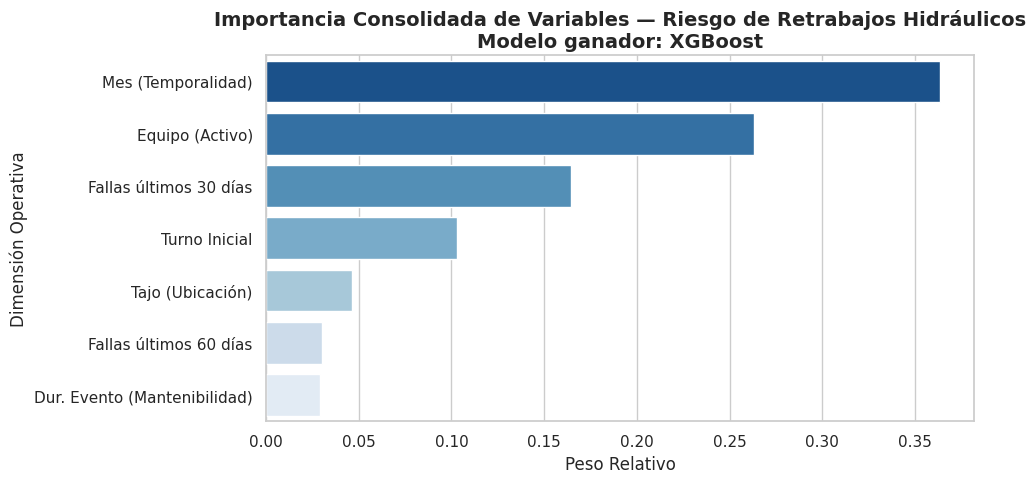


[...] Calculando valores SHAP (puede tardar 30-60 segundos)...
[✓] shap_values shape normalizado: (200, 60)

[Desplegando Gráfica SHAP — Summary Plot...]


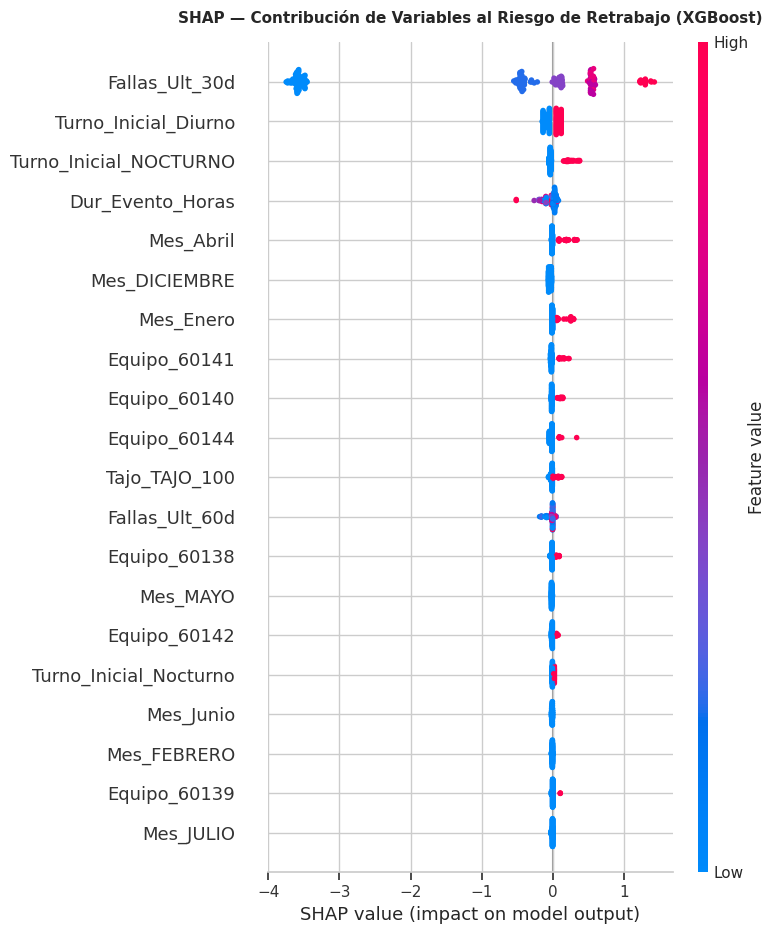


[Desplegando Gráfica SHAP — Dependence Plot Dur_Evento_Horas...]


<Figure size 1200x600 with 0 Axes>

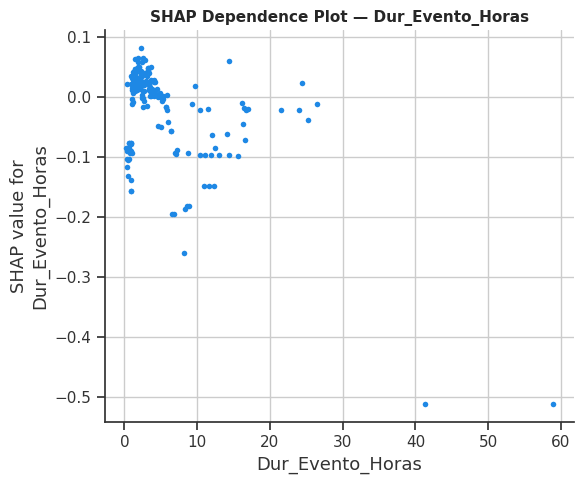


[Desplegando Gráfica SHAP — Dependence Plot Fallas_Ult_30d...]


<Figure size 1200x600 with 0 Axes>

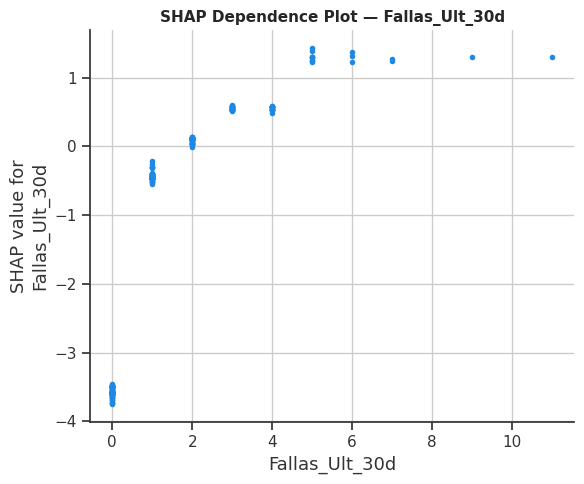


[i] Punto de inflexión aproximado (Dur_Evento_Horas): 1.12 horas

[Desplegando Gráfica SHAP — Caso de Mayor Riesgo Individual...]


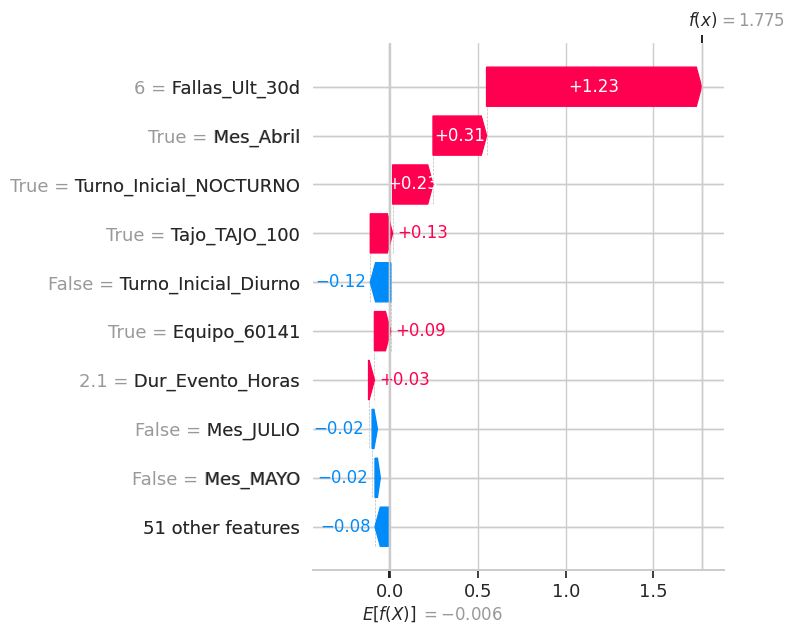

[✓] Caso analizado: probabilidad de retrabajo = 85.5%


In [20]:
# =====================================================================
#    BLOQUE 12: IMPORTANCIA DE VARIABLES Y SHAP
#    Se agregan SHAP Dependence Plots para
#    Dur_Evento_Horas y Fallas_Ult_30d, que revelan umbrales concretos
#    en vez de un solo número de importancia agregada.
# =====================================================================
print("\n==============================================================")
print(" BLOQUE 12: IMPORTANCIA DE VARIABLES E INTERPRETABILIDAD (SHAP) ")
print("================================================================")

# El modelo ganador es un Pipeline(SMOTE-Tomek, clasificador); para SHAP
# y feature_importances_ se usa el clasificador ya ajustado dentro del
# pipeline (el sampler no participa en inferencia).
modelo_shap = modelo_flota_activa.named_steps['clf']

# --- Importancia consolidada por dimensión operativa ---
importancias_dummies = modelo_shap.feature_importances_
nombres_dummies      = X_train.columns

importancias_por_origen = {
    'Equipo (Activo)'             : 0.0,
    'Turno Inicial'               : 0.0,
    'Mes (Temporalidad)'          : 0.0,
    'Tajo (Ubicación)'            : 0.0,
    'Dur. Evento (Mantenibilidad)': 0.0,
    'Fallas últimos 30 días'      : 0.0,
    'Fallas últimos 60 días'      : 0.0,
}

for nombre, peso in zip(nombres_dummies, importancias_dummies):
    if   'Equipo'         in nombre: importancias_por_origen['Equipo (Activo)']              += peso
    elif 'Turno'          in nombre: importancias_por_origen['Turno Inicial']                += peso
    elif 'Mes'            in nombre: importancias_por_origen['Mes (Temporalidad)']           += peso
    elif 'Tajo'           in nombre: importancias_por_origen['Tajo (Ubicación)']             += peso
    elif 'Dur_Evento'     in nombre: importancias_por_origen['Dur. Evento (Mantenibilidad)'] += peso
    elif 'Fallas_Ult_30d' in nombre: importancias_por_origen['Fallas últimos 30 días']       += peso
    elif 'Fallas_Ult_60d' in nombre: importancias_por_origen['Fallas últimos 60 días']       += peso

df_importancia = pd.DataFrame({
    'Variable Raíz'    : importancias_por_origen.keys(),
    'Importancia Total': importancias_por_origen.values()
}).sort_values(by='Importancia Total', ascending=False)

print("\n--- IMPORTANCIA CONSOLIDADA POR DIMENSIÓN OPERATIVA ---")
print(df_importancia.to_string(index=False))

plt.figure(figsize=(10, 5))
sns.barplot(data=df_importancia, x='Importancia Total', y='Variable Raíz',
            palette='Blues_r', hue='Variable Raíz', legend=False)
plt.title(f'Importancia Consolidada de Variables — Riesgo de Retrabajos Hidráulicos\n'
          f'Modelo ganador: {NOMBRE_MODELO_GANADOR}',
          fontsize=14, fontweight='bold')
plt.xlabel('Peso Relativo', fontsize=12)
plt.ylabel('Dimensión Operativa', fontsize=12)
plt.tight_layout()
plt.savefig('11_importancia_variables.png', dpi=300)
plt.show()

# --- SHAP ---
print("\n[...] Calculando valores SHAP (puede tardar 30-60 segundos)...")

explainer    = shap.TreeExplainer(modelo_shap)
muestra_shap = X_test.sample(min(200, len(X_test)), random_state=42)
shap_raw     = explainer.shap_values(muestra_shap)

# ── Normalizar al formato 2D (n_muestras, n_features) para clase 1 ──────────
if isinstance(shap_raw, list):
    shap_clase1 = shap_raw[1]
elif isinstance(shap_raw, np.ndarray) and shap_raw.ndim == 3:
    shap_clase1 = shap_raw[:, :, 1]
else:
    shap_clase1 = shap_raw

print(f"[✓] shap_values shape normalizado: {shap_clase1.shape}")

# Summary plot
print("\n[Desplegando Gráfica SHAP — Summary Plot...]")
plt.figure()
shap.summary_plot(shap_clase1, muestra_shap, show=False)
plt.title(f'SHAP — Contribución de Variables al Riesgo de Retrabajo ({NOMBRE_MODELO_GANADOR})',
          fontsize=11, fontweight='bold', pad=14)
plt.tight_layout()
plt.savefig('12_shap_summary.png', dpi=300, bbox_inches='tight')
plt.show()

# --- SHAP Dependence Plots (NUEVO — exigido por la revisión) ---
# Revelan el umbral no lineal exacto en el que cada variable empieza a
# empujar la predicción hacia el retrabajo, en vez de resumirla en un
# único número de importancia agregada.
print("\n[Desplegando Gráfica SHAP — Dependence Plot Dur_Evento_Horas...]")
plt.figure()
shap.dependence_plot('Dur_Evento_Horas', shap_clase1, muestra_shap, show=False,
                      interaction_index=None)
plt.title('SHAP Dependence Plot — Dur_Evento_Horas', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('13_shap_dependence_dur_evento.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n[Desplegando Gráfica SHAP — Dependence Plot Fallas_Ult_30d...]")
plt.figure()
shap.dependence_plot('Fallas_Ult_30d', shap_clase1, muestra_shap, show=False,
                      interaction_index=None)
plt.title('SHAP Dependence Plot — Fallas_Ult_30d', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('14_shap_dependence_fallas30d.png', dpi=300, bbox_inches='tight')
plt.show()

# Punto de inflexión aproximado de Dur_Evento_Horas (dónde el SHAP cruza
# de negativo a positivo), útil para redactar la regla de negocio.
idx_dur = list(muestra_shap.columns).index('Dur_Evento_Horas')
df_dep = pd.DataFrame({
    'valor': muestra_shap['Dur_Evento_Horas'].values,
    'shap' : shap_clase1[:, idx_dur],
}).sort_values('valor')
df_dep['shap_roll'] = df_dep['shap'].rolling(15, min_periods=5, center=True).mean()
cruce = df_dep.loc[df_dep['shap_roll'] > 0, 'valor']
punto_inflexion = float(cruce.iloc[0]) if len(cruce) > 0 else None
if punto_inflexion is not None:
    print(f"\n[i] Punto de inflexión aproximado (Dur_Evento_Horas): {punto_inflexion:.2f} horas")

# Waterfall para el caso de mayor riesgo
print("\n[Desplegando Gráfica SHAP — Caso de Mayor Riesgo Individual...]")
probas_test      = modelo_flota_activa.predict_proba(X_test)[:, 1]
idx_mayor_riesgo = probas_test.argmax()

shap_raw_full = explainer.shap_values(X_test)
if isinstance(shap_raw_full, list):
    shap_clase1_full = shap_raw_full[1]
elif isinstance(shap_raw_full, np.ndarray) and shap_raw_full.ndim == 3:
    shap_clase1_full = shap_raw_full[:, :, 1]
else:
    shap_clase1_full = shap_raw_full

if isinstance(explainer.expected_value, (list, np.ndarray)):
    base_val = float(np.array(explainer.expected_value).flatten()[1])
else:
    base_val = float(explainer.expected_value)

shap_fila_vals = shap_clase1_full[idx_mayor_riesgo]

try:
    shap_exp = shap.Explanation(
        values        = shap_fila_vals,
        base_values   = base_val,
        data          = X_test.iloc[idx_mayor_riesgo].values,
        feature_names = X_test.columns.tolist()
    )
    plt.figure()
    shap.waterfall_plot(shap_exp, show=False)
    plt.tight_layout()
    plt.savefig('15_shap_waterfall_caso_critico.png', dpi=300, bbox_inches='tight')
    plt.show()

except Exception as e:
    print(f"  [!] waterfall_plot no disponible ({e}). Generando bar plot alternativo.")

    df_shap_caso = pd.DataFrame({
        'Variable'    : X_test.columns.tolist(),
        'Contribución': shap_fila_vals.tolist()
    }).sort_values('Contribución', key=abs, ascending=False).head(10)

    colores_barra = ['#E8735A' if v > 0 else '#185FA5'
                     for v in df_shap_caso['Contribución']]
    plt.figure(figsize=(9, 5))
    plt.barh(df_shap_caso['Variable'], df_shap_caso['Contribución'],
             color=colores_barra)
    plt.axvline(x=0, color='black', linewidth=0.8)
    plt.title(f'SHAP — Variables más influyentes en el caso de mayor riesgo\n'
              f'Probabilidad de retrabajo: {probas_test[idx_mayor_riesgo]*100:.1f}%',
              fontsize=11, fontweight='bold')
    plt.xlabel('Contribución SHAP (+ empuja hacia retrabajo, − aleja)', fontsize=10)
    plt.tight_layout()
    plt.savefig('14_shap_waterfall_caso_critico.png', dpi=300, bbox_inches='tight')
    plt.show()

print(f"[✓] Caso analizado: probabilidad de retrabajo = "
      f"{probas_test[idx_mayor_riesgo]*100:.1f}%")


  BLOQUE 12B: VARIABLE 'MES' vs. CLIMA DE LA GUAJIRA            
[i] Intentando conectar a Open-Meteo...
[i] Rango de consulta: 2023-01-02 a 2026-07-15
[✓] Guardados los 1291 días detallados en: 'datos_climaticos_guajira_DIARIO.csv'
[i] Caché mensual 'datos_climaticos_guajira.csv' actualizado.

--- NORMALES CLIMATOLÓGICAS MENSUALES — LA GUAJIRA (CARIBE COLOMBIANO) ---
[Fuente: llamada EN VIVO a la Open-Meteo Historical Weather API (2023-01-02 → 2026-07-15, 1291 días, lat=11.1, lon=-72.59)]
 Mes  TempMaxMedia_C  Humedad_Media_pct
   1            30.9               75.4
   2            31.4               72.8
   3            32.8               69.5
   4            32.6               75.1
   5            33.1               77.4
   6            32.5               77.4
   7            33.2               73.5
   8            33.9               75.6
   9            33.3               80.7
  10            32.0               83.8
  11            31.0               82.4
  12            30.8    

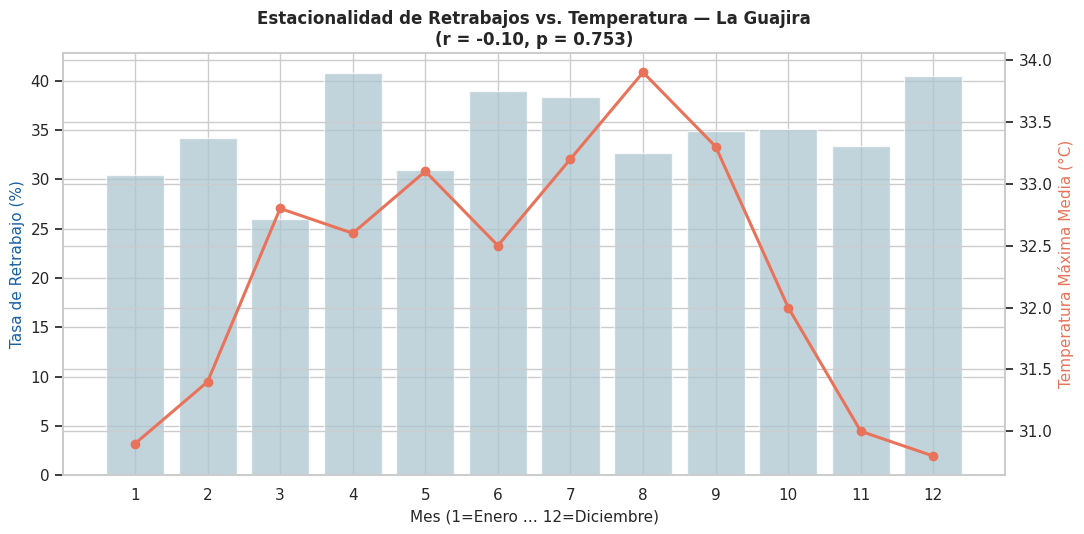

In [22]:
# =====================================================================
#    BLOQUE 12B: HIPÓTESIS CLIMÁTICA — LA VARIABLE "MES" COMO
#    PROXY TERMODINÁMICO (CLIMA REAL DE LA GUAJIRA EN VIVO)
# =====================================================================
print("\n==============================================================")
print("  BLOQUE 12B: VARIABLE 'MES' vs. CLIMA DE LA GUAJIRA            ")
print("================================================================")

RUTA_CLIMA_MENSUAL = 'datos_climaticos_guajira.csv'
RUTA_CLIMA_DIARIO = 'datos_climaticos_guajira_DIARIO.csv'
LAT_GUAJIRA, LON_GUAJIRA = 11.10, -72.59  # Zona de operación minera, La Guajira (Colombia)

df_clima = None
fuente_clima = None
df_diario_completo = None

try:
    # 1. Configurar rango de fechas de consulta seguro para Open-Meteo Archive
    fecha_inicio_api = pd.to_datetime(df_hidraulico['Fecha Hora Inicial'], format='mixed', errors='coerce').min().normalize()
    fecha_limite_archivo = pd.Timestamp.today().normalize() - pd.Timedelta(days=8)
    fecha_fin_api = min(
        pd.to_datetime(df_hidraulico['Fecha Hora Inicial'], format='mixed', errors='coerce').max().normalize(),
        fecha_limite_archivo
    )

    if fecha_inicio_api >= fecha_fin_api:
        fecha_inicio_api = fecha_fin_api - pd.Timedelta(days=30)

    print(f"[i] Intentando conectar a Open-Meteo...")
    print(f"[i] Rango de consulta: {fecha_inicio_api.strftime('%Y-%m-%d')} a {fecha_fin_api.strftime('%Y-%m-%d')}")

    # 2. Llamada en vivo a la API (solicitando temperatura, humedad y precipitación)
    resp = requests.get(
        "https://archive-api.open-meteo.com/v1/archive",
        params={
            "latitude": LAT_GUAJIRA,
            "longitude": LON_GUAJIRA,
            "start_date": fecha_inicio_api.strftime('%Y-%m-%d'),
            "end_date": fecha_fin_api.strftime('%Y-%m-%d'),
            "daily": "temperature_2m_max,precipitation_sum",
            "hourly": "relative_humidity_2m",
            "timezone": "America/Bogota",
        },
        timeout=15,
    )
    resp.raise_for_status()
    data = resp.json()

    # 3. Procesamiento y estructuración de datos climáticos diarios
    df_temp_diaria = pd.DataFrame({
        'fecha': pd.to_datetime(data['daily']['time']),
        'temp_max': data['daily']['temperature_2m_max'],
        'lluvia_mm': data['daily']['precipitation_sum'],
    })
    df_hum_horaria = pd.DataFrame({
        'fecha_hora': pd.to_datetime(data['hourly']['time']),
        'humedad': data['hourly']['relative_humidity_2m'],
    })

    # Consolidar humedad diaria promedio
    df_hum_diaria = (df_hum_horaria.assign(fecha=df_hum_horaria['fecha_hora'].dt.floor('D'))
                                    .groupby('fecha')['humedad'].mean().reset_index())

    # Crear histórico consolidado de n días
    df_diario_completo = df_temp_diaria.merge(df_hum_diaria, on='fecha', how='left')
    df_diario_completo['Mes'] = df_diario_completo['fecha'].dt.month
    df_diario_completo['Año'] = df_diario_completo['fecha'].dt.year

    # Guardar histórico detallado diario de respaldo
    df_diario_completo.to_csv(RUTA_CLIMA_DIARIO, index=False)
    print(f"[✓] Guardados los {len(df_diario_completo)} días detallados en: '{RUTA_CLIMA_DIARIO}'")

    # 4. Agrupar por mes para el reporte y gráficas mensuales existentes
    df_clima = (df_diario_completo.groupby('Mes')
                          .agg(TempMaxMedia_C=('temp_max', 'mean'),
                               Humedad_Media_pct=('humedad', 'mean'))
                          .round(1).reset_index())

    fuente_clima = (f"llamada EN VIVO a la Open-Meteo Historical Weather API "
                    f"({fecha_inicio_api.date()} → {fecha_fin_api.date()}, "
                    f"{len(df_diario_completo)} días, lat={LAT_GUAJIRA}, lon={LON_GUAJIRA})")

    df_clima.to_csv(RUTA_CLIMA_MENSUAL, index=False)
    print(f"[i] Caché mensual '{RUTA_CLIMA_MENSUAL}' actualizado.")

except Exception as e:
    print(f"[!] No se pudo completar la llamada en vivo a la API de Open-Meteo ({type(e).__name__}: {e}).")

    # PLAN DE RESPALDO: Intentar reconstruir desde el histórico diario guardado
    if os.path.exists(RUTA_CLIMA_DIARIO):
        print(f"[i] Reconstruyendo datos desde el histórico diario local '{RUTA_CLIMA_DIARIO}'...")
        df_diario_completo = pd.read_csv(RUTA_CLIMA_DIARIO)
        df_diario_completo['fecha'] = pd.to_datetime(df_diario_completo['fecha'])

        df_clima = (df_diario_completo.groupby('Mes')
                          .agg(TempMaxMedia_C=('temp_max', 'mean'),
                               Humedad_Media_pct=('humedad', 'mean'))
                          .round(1).reset_index())
        fuente_clima = f"reconstrucción desde el histórico diario local '{RUTA_CLIMA_DIARIO}'"
    elif os.path.exists(RUTA_CLIMA_MENSUAL):
        df_clima = pd.read_csv(RUTA_CLIMA_MENSUAL)
        fuente_clima = f"caché mensual antiguo '{RUTA_CLIMA_MENSUAL}'"
        print(f"[i] Se usa el {fuente_clima}.")
    else:
        print(f"[!] No se encontraron archivos de respaldo locales. Se omite el cruce climático.")

if df_clima is not None:
    print(f"\n--- NORMALES CLIMATOLÓGICAS MENSUALES — LA GUAJIRA (CARIBE COLOMBIANO) ---")
    print(f"[Fuente: {fuente_clima}]")
    print(df_clima.to_string(index=False))

    # Mapeo y cálculo de tasa de retrabajo mensual
    MESES_MAP = {
        'ENERO': 1, 'FEBRERO': 2, 'MARZO': 3, 'ABRIL': 4, 'MAYO': 5, 'JUNIO': 6,
        'JULIO': 7, 'AGOSTO': 8, 'SEPTIEMBRE': 9, 'OCTUBRE': 10, 'NOVIEMBRE': 11, 'DICIEMBRE': 12,
    }
    df_hidraulico['Mes_Num'] = df_hidraulico['Mes'].astype(str).str.strip().str.upper().map(MESES_MAP)

    resumen_mes = df_hidraulico.dropna(subset=['Mes_Num']).groupby('Mes_Num').agg(
        Total_Eventos=('Es_Retrabajo', 'count'),
        Retrabajos=('Es_Retrabajo', 'sum'),
    ).reset_index()
    resumen_mes['Tasa_Retrabajo_%'] = (resumen_mes['Retrabajos'] / resumen_mes['Total_Eventos'] * 100).round(2)
    resumen_mes = resumen_mes.merge(df_clima, left_on='Mes_Num', right_on='Mes', how='left')

    print("\n--- TASA DE RETRABAJOS POR MES vs. CLIMA (LA GUAJIRA) ---")
    cols_resumen = ['Mes_Num', 'Total_Eventos', 'Retrabajos', 'Tasa_Retrabajo_%',
                     'TempMaxMedia_C', 'Humedad_Media_pct']
    print(resumen_mes[cols_resumen].to_string(index=False))

    corr_temp, p_temp = pearsonr(resumen_mes['TempMaxMedia_C'], resumen_mes['Tasa_Retrabajo_%'])
    corr_hum,  p_hum  = pearsonr(resumen_mes['Humedad_Media_pct'], resumen_mes['Tasa_Retrabajo_%'])
    print(f"\n[i] Correlación de Pearson Temp. Máx. Media vs. Tasa de Retrabajo: r={corr_temp:.3f}  p={p_temp:.3f}")
    print(f"[i] Correlación de Pearson Humedad Media vs. Tasa de Retrabajo   : r={corr_hum:.3f}  p={p_hum:.3f}")

    # Gráfica de estacionalidad
    fig, ax1 = plt.subplots(figsize=(11, 5.5))
    ax1.bar(resumen_mes['Mes_Num'], resumen_mes['Tasa_Retrabajo_%'], color='#AEC6CF', alpha=0.75, label='Tasa de Retrabajo (%)')
    ax1.set_xlabel('Mes (1=Enero … 12=Diciembre)', fontsize=11)
    ax1.set_ylabel('Tasa de Retrabajo (%)', color='#185FA5', fontsize=11)
    ax1.set_xticks(range(1, 13))
    ax2 = ax1.twinx()
    ax2.plot(resumen_mes['Mes_Num'], resumen_mes['TempMaxMedia_C'], color='#E8735A', marker='o', lw=2.2, label='Temp. Máx. Media (°C)')
    ax2.set_ylabel('Temperatura Máxima Media (°C)', color='#E8735A', fontsize=11)
    plt.title(f'Estacionalidad de Retrabajos vs. Temperatura — La Guajira\n(r = {corr_temp:.2f}, p = {p_temp:.3f})', fontsize=12, fontweight='bold')
    fig.tight_layout()
    plt.savefig('16_estacionalidad_clima.png', dpi=300)
    plt.show()





  BLOQUE 12B_1: MAPA DE CALOR ESTACIONAL Y TÉRMICO               


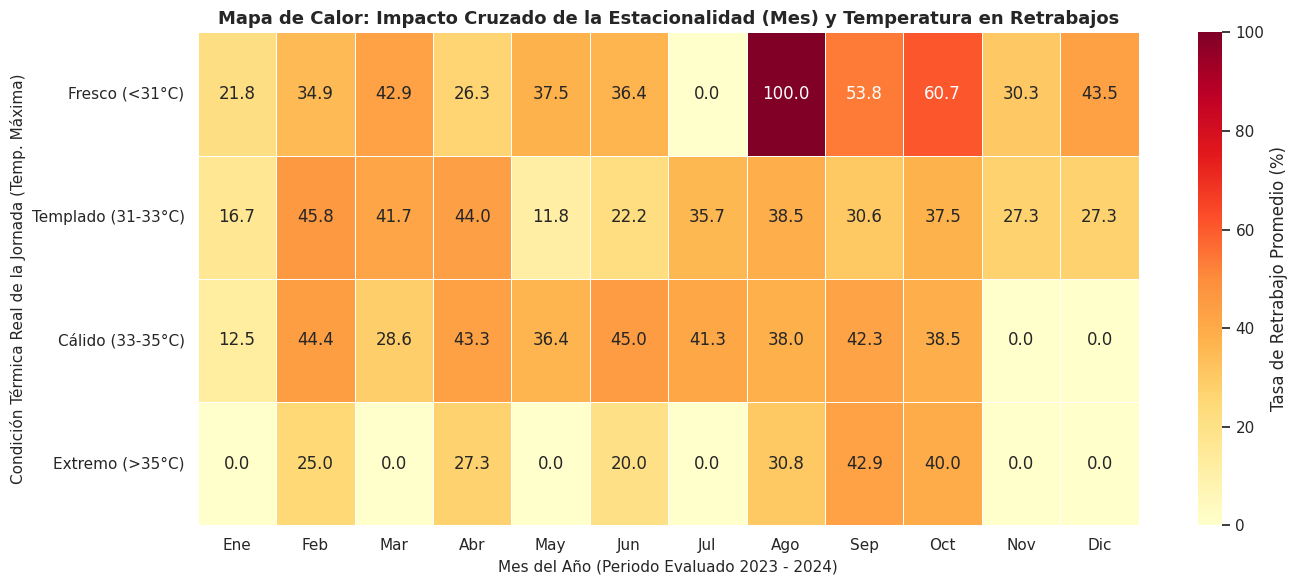

[✓] Mapa de calor termo-estacional generado y guardado como '14_mapa_calor_clima_retrabajos.png'.


In [23]:
# =====================================================================
#    BLOQUE 12B_1: MAPA DE CALOR ESTACIONAL Y TÉRMICO (CATEGORÍAS DE CALOR)
# =====================================================================
print("\n==============================================================")
print("  BLOQUE 12B_1: MAPA DE CALOR ESTACIONAL Y TÉRMICO               ")
print("================================================================")

try:
    if df_diario_completo is not None:
        # 1. Agrupar operaciones de la mina por fecha limpia
        df_hidraulico['fecha_limpia'] = pd.to_datetime(df_hidraulico['Fecha Hora Inicial'], format='mixed', errors='coerce').dt.normalize()
        resumen_diario_operaciones = df_hidraulico.groupby('fecha_limpia').agg(
            Total_Eventos=('Es_Retrabajo', 'count'),
            Total_Retrabajos=('Es_Retrabajo', 'sum')
        ).reset_index()

        # 2. Cruzar Operaciones con Clima Diario
        df_cruce_diario = df_diario_completo.merge(resumen_diario_operaciones, left_on='fecha', right_on='fecha_limpia', how='left')
        df_cruce_diario['Total_Eventos'] = df_cruce_diario['Total_Eventos'].fillna(0)
        df_cruce_diario['Total_Retrabajos'] = df_cruce_diario['Total_Retrabajos'].fillna(0)

        # 3. Agrupar por Rangos de Temperatura Máxima Real
        bins_temp = [0, 31, 33, 35, 50]
        labels_temp = ['Fresco (<31°C)', 'Templado (31-33°C)', 'Cálido (33-35°C)', 'Extremo (>35°C)']
        df_cruce_diario['Rango_Temperatura'] = pd.cut(df_cruce_diario['temp_max'], bins=bins_temp, labels=labels_temp)

        # 4. Crear matriz pivote
        matriz_clima_retrabajo = df_cruce_diario.groupby(['Rango_Temperatura', 'Mes']).agg(
            Suma_Eventos=('Total_Eventos', 'sum'),
            Suma_Retrabajos=('Total_Retrabajos', 'sum')
        ).reset_index()

        matriz_clima_retrabajo['Tasa_Retrabajo_%'] = (
            matriz_clima_retrabajo['Suma_Retrabajos'] / matriz_clima_retrabajo['Suma_Eventos'] * 100
        ).round(1)

        matriz_pivote_clima = matriz_clima_retrabajo.pivot_table(
            index='Rango_Temperatura', columns='Mes', values='Tasa_Retrabajo_%', aggfunc='mean'
        ).fillna(0)

        # Traducir meses del eje X
        meses_nombres = {1:'Ene', 2:'Feb', 3:'Mar', 4:'Abr', 5:'May', 6:'Jun',
                         7:'Jul', 8:'Ago', 9:'Sep', 10:'Oct', 11:'Nov', 12:'Dic'}
        matriz_pivote_clima.columns = [meses_nombres[c] for c in matriz_pivote_clima.columns]

        # 5. Graficar Mapa de Calor
        plt.figure(figsize=(14, 6))
        sns.heatmap(
            matriz_pivote_clima,
            cmap='YlOrRd',
            annot=True,
            fmt='.1f',
            linewidths=.7,
            cbar_kws={'label': 'Tasa de Retrabajo Promedio (%)'}
        )
        plt.title('Mapa de Calor: Impacto Cruzado de la Estacionalidad (Mes) y Temperatura en Retrabajos', fontsize=13, fontweight='bold')
        plt.xlabel('Mes del Año (Periodo Evaluado 2023 - 2024)', fontsize=11)
        plt.ylabel('Condición Térmica Real de la Jornada (Temp. Máxima)', fontsize=11)
        plt.tight_layout()
        plt.savefig('17_mapa_calor_clima_retrabajos.png', dpi=300)
        plt.show()
        print("[✓] Mapa de calor termo-estacional generado y guardado como '14_mapa_calor_clima_retrabajos.png'.")
    else:
        print("[!] No hay datos diarios disponibles para generar el mapa de calor.")
except Exception as e:
    print(f"[!] No se pudo generar el mapa de calor climático. Error: {e}")





  BLOQUE 12B_2: IMPACTO DE LA LLUVIA EN LOS RETRABAJOS            

--- COMPARATIVA CRUDA: DÍAS SECOS VS DÍAS LLUVIOSOS ---
Condicion_Dia  Dias_Totales  Total_Eventos  Total_Retrabajos  Tasa_Retrabajo_Consolidada_%
 Día Lluvioso           471            718               259                         36.07
     Día Seco           230            362               120                         33.15

--- ANALIZANDO EFECTO DE TRANSICIÓN (SECO DE REPENTE LLUVIA) ---
      Tipo_Transicion  Dias_Totales  Total_Eventos  Total_Retrabajos  Tasa_Retrabajo_%
Choque: Seco a Lluvia           117            182                64             35.16
       Estable / Seco           229            361               120             33.24
      Lluvia Continua           354            536               195             36.38
   Sin Datos (Inicio)             1              1                 0              0.00

[i] Correlación de Pearson (Cantidad de Lluvia mm vs Tasa Retrabajo Diaria):
    r = 0.029   p = 0.4

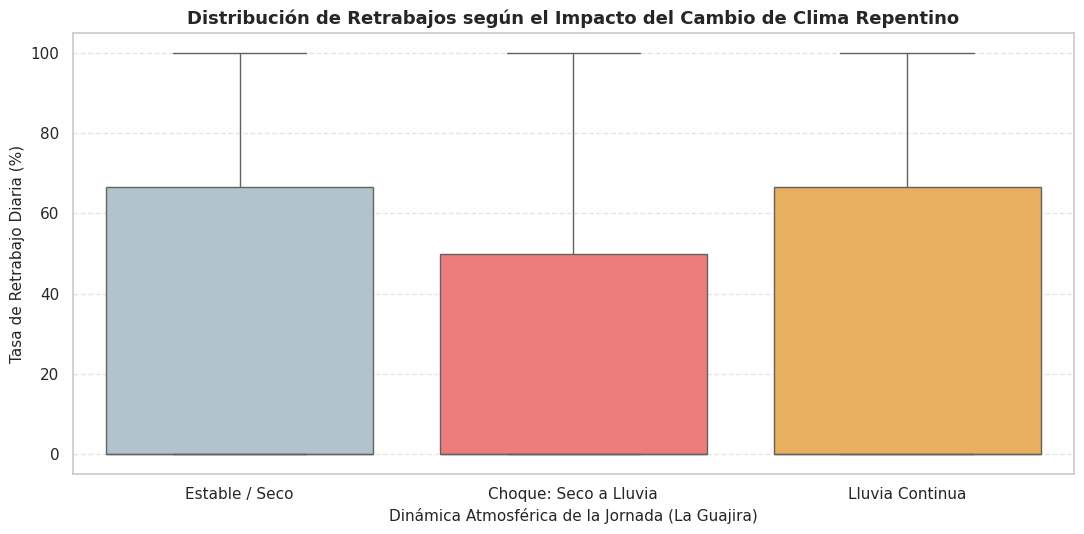

[✓] Análisis de lluvia y choque térmico completado. Gráfica guardada como '15_impacto_lluvia_retrabajos.png'.


In [24]:
# =====================================================================
#    BLOQUE 12B_2: IMPACTO DE LA LLUVIA Y EFECTO CHOQUE DE TRANSICIÓN
# =====================================================================
print("\n==============================================================")
print("  BLOQUE 12B_2: IMPACTO DE LA LLUVIA EN LOS RETRABAJOS            ")
print("================================================================")

try:
    if df_diario_completo is not None:
        # 1. Preparar df de cruce operativo diario
        df_hidraulico['fecha_limpia'] = pd.to_datetime(df_hidraulico['Fecha Hora Inicial'], format='mixed', errors='coerce').dt.normalize()
        resumen_diario_ops = df_hidraulico.groupby('fecha_limpia').agg(
            Total_Eventos=('Es_Retrabajo', 'count'),
            Total_Retrabajos=('Es_Retrabajo', 'sum')
        ).reset_index()

        df_lluvia_cruce = df_diario_completo.merge(resumen_diario_ops, left_on='fecha', right_on='fecha_limpia', how='inner')
        df_lluvia_cruce['Tasa_Retrabajo_%'] = (df_lluvia_cruce['Total_Retrabajos'] / df_lluvia_cruce['Total_Eventos'] * 100).round(2)

        # 2. Análisis Binario: Día Seco vs. Día de Lluvia
        df_lluvia_cruce['Condicion_Dia'] = df_lluvia_cruce['lluvia_mm'].apply(lambda x: 'Día Lluvioso' if x > 0.2 else 'Día Seco')

        analisis_binario = df_lluvia_cruce.groupby('Condicion_Dia').agg(
            Dias_Totales=('fecha', 'count'),
            Total_Eventos=('Total_Eventos', 'sum'),
            Total_Retrabajos=('Total_Retrabajos', 'sum')
        ).reset_index()
        analisis_binario['Tasa_Retrabajo_Consolidada_%'] = (analisis_binario['Total_Retrabajos'] / analisis_binario['Total_Eventos'] * 100).round(2)

        print("\n--- COMPARATIVA CRUDA: DÍAS SECOS VS DÍAS LLUVIOSOS ---")
        print(analisis_binario.to_string(index=False))

        # 3. Análisis de Choque de Transición (Seco de Repente Lluvia)
        print("\n--- ANALIZANDO EFECTO DE TRANSICIÓN (SECO DE REPENTE LLUVIA) ---")
        df_lluvia_cruce = df_lluvia_cruce.sort_values('fecha').reset_index(drop=True)
        df_lluvia_cruce['Lluvia_Dia_Anterior'] = df_lluvia_cruce['lluvia_mm'].shift(1)

        def clasificar_transicion(row):
            if pd.isna(row['Lluvia_Dia_Anterior']):
                return 'Sin Datos (Inicio)'
            elif row['Lluvia_Dia_Anterior'] <= 0.2 and row['lluvia_mm'] > 0.2:
                return 'Choque: Seco a Lluvia'
            elif row['Lluvia_Dia_Anterior'] > 0.2 and row['lluvia_mm'] > 0.2:
                return 'Lluvia Continua'
            else:
                return 'Estable / Seco'

        df_lluvia_cruce['Tipo_Transicion'] = df_lluvia_cruce.apply(clasificar_transicion, axis=1)

        analisis_choque = df_lluvia_cruce.groupby('Tipo_Transicion').agg(
            Dias_Totales=('fecha', 'count'),
            Total_Eventos=('Total_Eventos', 'sum'),
            Total_Retrabajos=('Total_Retrabajos', 'sum')
        ).reset_index()
        analisis_choque['Tasa_Retrabajo_%'] = (analisis_choque['Total_Retrabajos'] / analisis_choque['Total_Eventos'] * 100).round(2)
        print(analisis_choque.to_string(index=False))

        # 4. Correlación Numérica de Lluvia
        df_filtrado_analisis = df_lluvia_cruce[df_lluvia_cruce['Total_Eventos'] > 0]
        corr_lluvia, p_lluvia = pearsonr(df_filtrado_analisis['lluvia_mm'], df_filtrado_analisis['Tasa_Retrabajo_%'])
        print(f"\n[i] Correlación de Pearson (Cantidad de Lluvia mm vs Tasa Retrabajo Diaria):")
        print(f"    r = {corr_lluvia:.3f}   p = {p_lluvia:.3f}")

        # 5. Graficar la distribución por tipo de transición climática
        plt.figure(figsize=(11, 5.5))
        df_grafica_choque = df_filtrado_analisis[df_filtrado_analisis['Tipo_Transicion'] != 'Sin Datos (Inicio)']

        sns.boxplot(
            x='Tipo_Transicion',
            y='Tasa_Retrabajo_%',
            data=df_grafica_choque,
            palette=['#AEC6CF', '#FF6B6B', '#FFB347'],
            fliersize=4,
            order=['Estable / Seco', 'Choque: Seco a Lluvia', 'Lluvia Continua']
        )
        plt.title('Distribución de Retrabajos según el Impacto del Cambio de Clima Repentino', fontsize=13, fontweight='bold')
        plt.xlabel('Dinámica Atmosférica de la Jornada (La Guajira)', fontsize=11)
        plt.ylabel('Tasa de Retrabajo Diaria (%)', fontsize=11)
        plt.grid(axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.savefig('18_impacto_lluvia_retrabajos.png', dpi=300)
        plt.show()
        print("[✓] Análisis de lluvia y choque térmico completado. Gráfica guardada como '15_impacto_lluvia_retrabajos.png'.")
    else:
        print("[!] No hay datos diarios de lluvia para procesar en este bloque.")
except Exception as e:
    print(f"[!] Error en el bloque de análisis de lluvia: {e}")


  BLOQUE 12C: SHAP INTERACTION VALUES (INTERACCIONES DE PARES)  
[...] Calculando SHAP Interaction Values (matriz N×F×F, puede tardar 1-2 minutos)...

--- TOP 10 PARES DE VARIABLES CON MAYOR INTERACCIÓN SHAP ---
      Variable_A             Variable_B  Interaccion_Media_Abs
  Fallas_Ult_30d   Turno_Inicial_Diurno               0.028554
  Fallas_Ult_60d              Mes_Enero               0.019123
Dur_Evento_Horas         Fallas_Ult_30d               0.017823
  Fallas_Ult_30d           Equipo_60144               0.015001
  Fallas_Ult_30d Turno_Inicial_NOCTURNO               0.013153
  Fallas_Ult_30d          Tajo_TAJO_100               0.011926
  Fallas_Ult_30d         Fallas_Ult_60d               0.011211
  Fallas_Ult_30d          Mes_DICIEMBRE               0.010416
       Mes_Abril          Tajo_TAJO_100               0.010374
  Fallas_Ult_30d              Mes_Abril               0.007734

[Desplegando Gráfica — Top 10 Interacciones SHAP...]


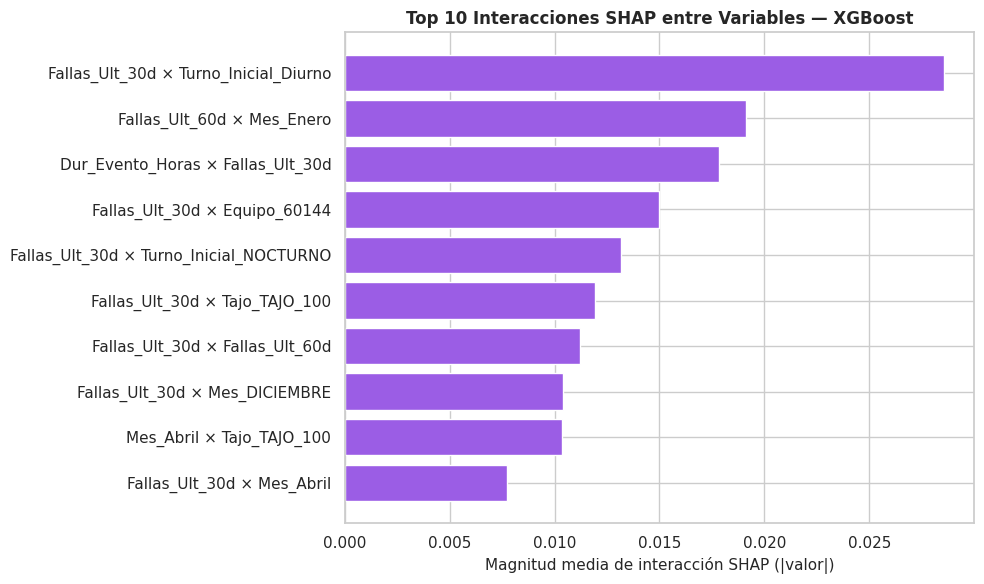


[i] La interacción más fuerte fue Fallas_Ult_30d × Turno_Inicial_Diurno (0.0286), lo que sugiere que el riesgo de retrabajo no depende de esas dos variables por separado, sino de su combinación específica.


In [25]:
# =====================================================================
#    BLOQUE 12C (RONDA 2): SHAP INTERACTION VALUES
# =====================================================================
print("\n==============================================================")
print("  BLOQUE 12C: SHAP INTERACTION VALUES (INTERACCIONES DE PARES)  ")
print("================================================================")
print("[...] Calculando SHAP Interaction Values (matriz N×F×F, puede tardar 1-2 minutos)...")

muestra_interaction = X_test.sample(min(100, len(X_test)), random_state=42)  # muestra menor: costo O(F²)
try:
    shap_interaction = explainer.shap_interaction_values(muestra_interaction)
    if isinstance(shap_interaction, list):
        shap_interaction = shap_interaction[1]
    elif isinstance(shap_interaction, np.ndarray) and shap_interaction.ndim == 4:
        shap_interaction = shap_interaction[:, :, :, 1]

    # Magnitud media de interacción por par de variables (fuera de la diagonal)
    interaction_abs_mean = np.abs(shap_interaction).mean(axis=0)  # F × F
    n_feat = interaction_abs_mean.shape[0]
    pares = []
    for i in range(n_feat):
        for j in range(i + 1, n_feat):
            pares.append((muestra_interaction.columns[i], muestra_interaction.columns[j],
                          interaction_abs_mean[i, j]))
    df_interacciones = pd.DataFrame(
        pares, columns=['Variable_A', 'Variable_B', 'Interaccion_Media_Abs']
    ).sort_values('Interaccion_Media_Abs', ascending=False)

    print("\n--- TOP 10 PARES DE VARIABLES CON MAYOR INTERACCIÓN SHAP ---")
    print(df_interacciones.head(10).to_string(index=False))

    top10 = df_interacciones.head(10).iloc[::-1]
    print("\n[Desplegando Gráfica — Top 10 Interacciones SHAP...]")
    plt.figure(figsize=(10, 6))
    plt.barh([f"{a} × {b}" for a, b in zip(top10['Variable_A'], top10['Variable_B'])],
              top10['Interaccion_Media_Abs'], color='#9B5DE5')
    plt.xlabel('Magnitud media de interacción SHAP (|valor|)', fontsize=11)
    plt.title(f'Top 10 Interacciones SHAP entre Variables — {NOMBRE_MODELO_GANADOR}',
              fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('19_shap_interaction_values.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"\n[i] La interacción más fuerte fue "
          f"{df_interacciones.iloc[0]['Variable_A']} × {df_interacciones.iloc[0]['Variable_B']} "
          f"({df_interacciones.iloc[0]['Interaccion_Media_Abs']:.4f}), lo que sugiere que el riesgo de "
          f"retrabajo no depende de esas dos variables por separado, sino de su combinación específica.")
except Exception as e:
    print(f"[!] No se pudieron calcular SHAP Interaction Values para {NOMBRE_MODELO_GANADOR} ({e}). "
          f"Nota: TreeExplainer soporta shap_interaction_values de forma nativa para XGBoost, Random "
          f"Forest y LightGBM; CatBoost puede requerir una versión específica de la librería shap.")

In [26]:
# =====================================================================
#    BLOQUE  13: ANÁLISIS COSTO-BENEFICIO DEL MODELO PREDICTIVO
#    VP/FN/FP/VN: se calculan de la
#    matriz de confusión real del modelo ganador. Se agrega la Función
#    de Pérdida Esperada como formalización matemática del análisis.
# =====================================================================
print("\n=============================================================")
print(" BLOQUE 13: ANÁLISIS COSTO-BENEFICIO — IMPACTO FINANCIERO DEL MODELO    ")
print("===============================================================")

# ── Parámetros financieros del contrato ──────────────────────────────
# Basados en benchmarks de la industria minera (Sari et al., 2023) y en
# los datos operativos observados en el dataset histórico.
COSTO_HORA_DOWNTIME        = 5_000   # USD/hora — costo por hora de pala parada en tajo
HORAS_PROMEDIO_RETRABAJO   = 3.86    # horas — MTTR promedio observado en el dataset
COSTO_INSPECCION_ADICIONAL = 500     # USD — costo de una inspección FP (técnico + logística)
COSTO_FN_TAJO              = 15_000  # USD — costo de avería no detectada en plena operación

# ─ Resultados reales del modelo ganador sobre el set de prueba ───
VN, FP = cm[0]
FN, VP = cm[1]
VN, FP, FN, VP = int(VN), int(FP), int(FN), int(VP)

print(f"\n[i] Matriz de confusión del modelo ganador ({NOMBRE_MODELO_GANADOR}):")
print(f"    Verdaderos Positivos (VP): {VP}   Falsos Negativos (FN): {FN}")
print(f"    Falsos Positivos    (FP): {FP}   Verdaderos Negativos (VN): {VN}")

# ── Formalización: Función de Pérdida Esperada ─────────────────
#   E[L(τ)] = C_FN · FN(τ) + C_FP · FP(τ)
# Con τ=0,5 (umbral por defecto) y los valores observados de FN y FP:
costo_sin_modelo = (VP + FN) * COSTO_FN_TAJO  # escenario reactivo: todos los retrabajos llegan al tajo
costo_FP_con_modelo = FP * COSTO_INSPECCION_ADICIONAL
costo_FN_con_modelo = FN * COSTO_FN_TAJO
costo_con_modelo = costo_FP_con_modelo + costo_FN_con_modelo   # = E[L(0,5)]

ahorro_neto = costo_sin_modelo - costo_con_modelo
roi = (ahorro_neto / costo_con_modelo) * 100 if costo_con_modelo else float('nan')

print(f"\n[Función de Pérdida Esperada] E[L(0,5)] = C_FN·FN + C_FP·FP "
      f"= {COSTO_FN_TAJO}×{FN} + {COSTO_INSPECCION_ADICIONAL}×{FP} = ${costo_con_modelo:,.0f} USD")

print(f"\n{'─'*60}")
print(f"  ESCENARIO SIN MODELO (mantenimiento reactivo)")
print(f"{'─'*60}")
print(f"  Retrabajos totales en set de prueba : {VP + FN}")
print(f"  Todos llegan al tajo sin alerta      : {VP + FN} × ${COSTO_FN_TAJO:,} USD")
print(f"  Costo total estimado                 : ${costo_sin_modelo:,.0f} USD")

print(f"\n{'─'*60}")
print(f"  ESCENARIO CON MODELO (mantenimiento predictivo)")
print(f"{'─'*60}")
print(f"  Retrabajos detectados (VP)   : {VP} × $0 (evitados)")
print(f"  Falsas alarmas (FP)          : {FP} × ${COSTO_INSPECCION_ADICIONAL:,} USD")
print(f"  Retrabajos no detectados (FN): {FN} × ${COSTO_FN_TAJO:,} USD")
print(f"  Costo total estimado         : ${costo_con_modelo:,.0f} USD")

print(f"\n{'═'*60}")
print(f"  AHORRO NETO DEL MODELO        : ${ahorro_neto:,.0f} USD")
print(f"  ROI del sistema analítico     : {roi:.1f}%")
print(f"  Retrabajos evitados           : {VP} de {VP+FN} ({VP/(VP+FN)*100:.1f}%)")
print(f"{'═'*60}")

# Proyección anual (el set de prueba = últimos 6 meses aprox.)
ahorro_anual = ahorro_neto * 2
print(f"\n[i] Proyección anual (×2 semestres): ${ahorro_anual:,.0f} USD")
print(f"[i] Costo de desarrollo del sistema : ~$8,000 USD (estimado)")
print(f"[i] Payback estimado                : < 1 semana de operación")


 BLOQUE 13: ANÁLISIS COSTO-BENEFICIO — IMPACTO FINANCIERO DEL MODELO    

[i] Matriz de confusión del modelo ganador (XGBoost):
    Verdaderos Positivos (VP): 44   Falsos Negativos (FN): 21
    Falsos Positivos    (FP): 39   Verdaderos Negativos (VN): 118

[Función de Pérdida Esperada] E[L(0,5)] = C_FN·FN + C_FP·FP = 15000×21 + 500×39 = $334,500 USD

────────────────────────────────────────────────────────────
  ESCENARIO SIN MODELO (mantenimiento reactivo)
────────────────────────────────────────────────────────────
  Retrabajos totales en set de prueba : 65
  Todos llegan al tajo sin alerta      : 65 × $15,000 USD
  Costo total estimado                 : $975,000 USD

────────────────────────────────────────────────────────────
  ESCENARIO CON MODELO (mantenimiento predictivo)
────────────────────────────────────────────────────────────
  Retrabajos detectados (VP)   : 44 × $0 (evitados)
  Falsas alarmas (FP)          : 39 × $500 USD
  Retrabajos no detectados (FN): 21 × $15,000 USD

In [29]:
# =====================================================================
#    BLOQUE  14: EXPORTACIÓN DEL DATASET PARA POWER BI
# =====================================================================
print("\n===============================================================")
print("  BLOQUE  14: EXPORTACIÓN AUTOMÁTICA DEL DATASET PARA POWER BI   ")
print("=================================================================")

import pandas as pd

# 1. Recuperamos df_flota_activa
if 'df_flota_activa' in globals():

    df_export = globals()['df_flota_activa'].copy()
else:
    raise NameError(
        "La variable 'df_flota_activa' no se encuentra en memoria. "
        "Por favor, ejecuta primero el bloque del ETL."
    )

# 2. Recuperamos de forma segura el nombre del modelo ganador
modelo_ganador = globals().get('NOMBRE_MODELO_GANADOR', 'Modelo Calibrado (XGBoost/LightGBM)')

# Calculamos el MTFS general para toda la flota activa (todos los sistemas)
df_export['Fecha_Hora_Inicial_DT'] = pd.to_datetime(
    df_export['Fecha Hora Inicial'], format='mixed', errors='coerce'
)
df_export = df_export.sort_values(
    by=['Equipo', 'SISTEMA', 'Fecha_Hora_Inicial_DT']
)
df_export['Fecha_Evento_Anterior'] = (
    df_export.groupby(['Equipo', 'SISTEMA'])['Fecha_Hora_Inicial_DT'].shift(1)
)
df_export['Dias_Desde_Ultima_Falla'] = (
    df_export['Fecha_Hora_Inicial_DT'] - df_export['Fecha_Evento_Anterior']
).dt.total_seconds() / (24 * 3600)

df_export['Es_Retrabajo_Calidad'] = df_export['Dias_Desde_Ultima_Falla'].apply(
    lambda x: 1 if (not pd.isna(x) and x <= 5.0) else 0
)
df_export['Hora_Militar_Ocurrencia'] = df_export['Fecha_Hora_Inicial_DT'].dt.hour
df_export['Equipo_Nombre']           = "Pala " + df_export['Equipo'].astype(str)
df_export['Dias_Desde_Ultima_Falla'] = df_export['Dias_Desde_Ultima_Falla'].round(2)

columnas_exportacion = [
    'Flotas', 'Equipo_Nombre', 'Work Order EV', 'WO Desc', 'WO AMT (Primaria)',
    'Fecha Hora Inicial', 'Fecha Hora Final', 'Hora_Militar_Ocurrencia',
    'SISTEMA', 'SUB SISTEMA', 'CORRECTIVO', 'Parte', 'Tipos OTs', 'Tipo Evento',
    'Semana MTO (Inicio EV)', 'Tajo', 'Año', 'Mes', 'Horas_Down_Numeric',
    'Dias_Desde_Ultima_Falla', 'Es_Retrabajo_Calidad'
]

# Exportar solo las columnas que existan en el DataFrame
columnas_validas = [c for c in columnas_exportacion if c in df_export.columns]

nombre_salida_pbi = "DB_AMT_FlotaActiva_Limpio.csv"
df_export[columnas_validas].to_csv(
    nombre_salida_pbi, index=False, encoding='utf-8-sig'
)

print(f"[✓] Archivo Power BI generado : '{nombre_salida_pbi}'")
print(f"[✓] Registros exportados      : {len(df_export):,} filas")
print(f"[✓] Columnas exportadas       : {len(columnas_validas)}")

# Resumen final de archivos generados
print("\n================================================================")
print("   RESUMEN DE ARCHIVOS GENERADOS                                ")
print("================================================================")
archivos = [
    ('1_radiografia_flota_activa.png',        'Gráfica 1  — Línea base downtime por activo'),
    ('2_tasa_retrabajos_flota_activa.png',    'Gráfica 2  — Tasa de retrabajos MTFS por pala'),
    ('3_weibull_mtfs.png',                    'Gráfica 3  — Ajuste de Weibull '),
    ('4_boxplot_auc_kfold.png',               'Gráfica 4  — Distribución AUC por Fold'),
    ('5_tabla_comparativa_modelos.png',       'Gráfica 5  — Tabla comparativa modelos'),
    ('6_umbral_costo.png',                    'Gráfica 6  — urva de operación sensibleal costo'),
    ('7_5x2cv_boxplot.png',                   'Gráfica 7  — Estrategia desbalance XGBoots'),
    ('8_curva_roc_comparativa.png',           'Gráfica 8  — Curva ROC Comparativa'),
    ('9_curva_precision_recall.png',          'Gráfica 9  — Curva Precision-Recall'),
    ('10_reliability_diagram.png',            'Gráfica 10 — eliability Diagram (Calibración'),
    ('11_importancia_variables.png',          'Gráfica 11 — Importancia Consolidada de Variables'),
    ('12_shap_summary.png',                   'Gráfica 12 — Contribución variable risgo retrabajo'),
    ('13_shap_dependence_dur_evento.png',     'Gráfica 13 — Dependence Plot Dur_Evento_Horas'),
    ('14_shap_dependence_fallas30d.png',      'Gráfica 14 — Dependence Plot Fallas_Ult_30d)'),
    ('15_shap_waterfall_caso_critico.png',    'Gráfica 15 — Variables más influyentes en riesgo'),
    ('16_estacionalidad_clima.png',           'Gráfica 16 — Estimación retrabajo & la temperatura'),
    ('17_mapa_calor_clima_retrabajos.png',    'Gráfica 17 — Mapa de calor termo-estacional'),
    ('18_simpacto_lluvia_retrabajos.png',     'Gráfica 18 — hap_interaction_values'),
    ('19_shap_interaction_values.png',        'Gráfica 19 — ATop 10 Interacciones SHA'),
    (nombre_salida_pbi,                       'Dataset    — Power BI listo'),
]
for archivo, descripcion in archivos:
    print(f"  {descripcion:<50} → {archivo}")

print(f"\n[✓] Modelo ganador final: {modelo_ganador}")
print("\n================================================================")
print("   PROCESAMIENTO FINALIZADO CON ÉXITO                          ")
print("================================================================")


  BLOQUE  14: EXPORTACIÓN AUTOMÁTICA DEL DATASET PARA POWER BI   
[✓] Archivo Power BI generado : 'DB_AMT_FlotaActiva_Limpio.csv'
[✓] Registros exportados      : 4,125 filas
[✓] Columnas exportadas       : 21

   RESUMEN DE ARCHIVOS GENERADOS                                
  Gráfica 1  — Línea base downtime por activo        → 1_radiografia_flota_activa.png
  Gráfica 2  — Tasa de retrabajos MTFS por pala      → 2_tasa_retrabajos_flota_activa.png
  Gráfica 3  — Ajuste de Weibull                     → 3_weibull_mtfs.png
  Gráfica 4  — Distribución AUC por Fold             → 4_boxplot_auc_kfold.png
  Gráfica 5  — Tabla comparativa modelos             → 5_tabla_comparativa_modelos.png
  Gráfica 6  — urva de operación sensibleal costo    → 6_umbral_costo.png
  Gráfica 7  — Estrategia desbalance XGBoots         → 7_5x2cv_boxplot.png
  Gráfica 8  — Curva ROC Comparativa                 → 8_curva_roc_comparativa.png
  Gráfica 9  — Curva Precision-Recall                → 9_curva_precision_rec